In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [2]:
import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
from flax import linen as nn
import optax
import copy

from typing import Callable

from functools import partial

import tensorflow as tf
import tensorrt

from pyDOE import lhs
import numpy as np
from matplotlib import cm
import matplotlib.pyplot as plt

from scipy.integrate import odeint

import numpy as np

from jax.scipy.optimize import minimize
from scipy.optimize import fsolve

import warnings
import math

from collections import deque

import scipy

2025-03-24 09:15:29.618042: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1742816729.631176  940912 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1742816729.635229  940912 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
def flatten_pytree(params):
  values, tree_info = jax.tree_util.tree_flatten(params)

  no_leaves = len(values)
  shapes = []
  flattened = []

  for i in range(no_leaves):
    flattened.append(values[i].flatten())
    shapes.append(values[i].shape)

  return tree_info, shapes, jnp.concatenate(flattened)


def reconstruct_pytree(tree_info, shapes, flattened):

  values = []
  k = 0
  for i in range(len(shapes)):
    values.append(np.reshape(flattened[k:k+np.prod(shapes[i])], shapes[i]))
    k += np.prod(shapes[i])

  py_tree = jax.tree_util.tree_unflatten(tree_info, values)
  return py_tree

In [4]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [5]:
print(jax.default_backend())

gpu


In [6]:
t0, tfinal = 0.0, 2.5

In [7]:
k = 1.0
l = 2.0

k_sqr = k**2
l_sqr = l**2

In [8]:
def Lorenz1960(vals, t):

  A_val, F_val, G_val = vals

  A_t = -(1/(k**2) - 1/(k**2 + l**2))*(k * l * F_val * G_val)
  F_t = (1/(l**2) - 1/(k**2 + l**2))*(k * l * A_val * G_val)
  G_t = -(1/2)*(1/(l**2) - 1/(k**2))*(k * l * A_val * F_val)

  vals_t = [A_t, F_t, G_t]

  return vals_t

In [9]:
@jax.jit
def calc_EV(A, F, G) :

    E = (1/4)*((A**2/l**2) + (F**2/k**2) + (2*(G**2)/(k**2 + l**2)))
    V = (1/2)*(A**2 + F**2 + 2*(G**2))

    return E, V

In [10]:
class Normalize(nn.Module):
  xmin: float
  xmax: float

  @nn.compact
  def __call__(self, x):
    return 2.0*(x-self.xmin)/(self.xmax - self.xmin) - 1.0

In [11]:
class HardConstraint(nn.Module):
  t0: float
  tfinal: float
  u0: float

  @nn.compact
  def __call__(self, inputs):
    t, nn = inputs
    return self.u0 + (t-self.t0)/(self.tfinal-self.t0)*nn

In [12]:
class CombineBranches(nn.Module):
  @nn.compact
  def __call__(self, inp1, inp2):
    mult = jnp.sum(inp1*inp2, axis=1)
    out = jnp.reshape(mult, (-1,1))
    return out

In [13]:
class MLP(nn.Module):

  layers: int
  units: int

  @nn.compact
  def __call__(self, inp):
    b = inp
    for i in range(self.layers-1):
      b = nn.Dense(self.units)(b)
      b = nn.tanh(b)
    out = nn.Dense(3*self.units)(b)
    return out

In [14]:
def define_collocation_points(t_bdry, N=100):

  ode_points = t_bdry[0] + (t_bdry[1] - t_bdry[0])*lhs(1, N)

  As = np.random.uniform(-1.0, 1.0, size = (N, 1))
  Fs = np.random.uniform(-1.0, 1.0, size = (N, 1))
  Gs = np.random.uniform(-1.0, 1.0, size = (N, 1))
  Es = (1/4)*((As**2/l**2) + (Fs**2/k**2) + (2*(Gs**2)/(k**2 + l**2)))
  Vs = (1/2)*(As**2 + Fs**2 + 2*(Gs**2))

  ode_points = np.column_stack((ode_points, Es, Vs))
  sensor_points = np.column_stack((As, Fs, Gs))

  return (ode_points, sensor_points)

In [15]:
(de_points, zsensors) = define_collocation_points([t0, tfinal], 1000)
print(de_points.shape, zsensors.shape)

(1000, 3) (1000, 3)


In [16]:
Emin = 0.0
Emax = (1/4)*((1.0**2/l**2) + (1.0**2/k**2) + (2*(1.0**2)/(k**2 + l**2)))
Vmin = 0.0
Vmax = (1/2)*(1.0**2 + 1.0**2 + 2*(1.0**2))

print(Emax, Vmax)

0.4125 2.0


In [17]:
class VDeepONet(nn.Module):

  t0: float
  tfinal: float
  layers: int
  units: int

  @nn.compact
  def __call__(self, tEV, u):

    if u.ndim == 1:
      u = jnp.reshape(u, (1,-1))
      
    if tEV.ndim == 1:
      tEV = jnp.reshape(tEV, (1,-1))
        
    t_0 = tEV[:, :1]
    E_0 = tEV[:, 1:2]
    V_0 = tEV[:, 2:]
      
    t_0 = jnp.reshape(t_0, (-1,1))
    t_0_norm = Normalize(self.t0, self.tfinal)(t_0)

    b = t_0_norm
      
    A_0 = u[:,:1]
    F_0 = u[:,1:2]
    G_0 = u[:,2:3]
                         
    trunk_net = MLP(self.layers, self.units)(b)
    branch_net = MLP(self.layers, self.units)(u)

    A_tr = trunk_net[:, :self.units]
    F_tr = trunk_net[:, self.units:2*self.units]
    G_tr = trunk_net[:, 2*self.units:]

    A_br = branch_net[:, :self.units]
    F_br = branch_net[:, self.units:2*self.units]
    G_br = branch_net[:, 2*self.units:]

    A = CombineBranches()(A_tr, A_br)
    F = CombineBranches()(F_tr, F_br)
    G = CombineBranches()(G_tr, G_br)

    A = HardConstraint(self.t0, self.tfinal, A_0)([t_0, A])
    F = HardConstraint(self.t0, self.tfinal, F_0)([t_0, F])
    G = HardConstraint(self.t0, self.tfinal, G_0)([t_0, G])

    A = jnp.reshape(A, (-1,))
    F = jnp.reshape(F, (-1,))
    G = jnp.reshape(G, (-1,))

    E = (0.25)*((A**2/l**2) + (F**2/k**2) + (2.*(G**2)/(k**2 + l**2)))
    V = (0.5)*(A**2 + F**2 + 2.*(G**2))

    return A, F, G, E, V

In [18]:
@partial(jax.jit, static_argnums=(2,))
def Vvar_model(t, z, component, params):
  return Vdeeponet.apply(params, t, z)[component][0]

@partial(jax.jit, static_argnums=(2,))
def Vvar(t, z, component, params):
  return jax.vmap(Vvar_model, [0, 0, None, None])(t, z, component, params)

@partial(jax.jit, static_argnums=(2,))
def Vvar_t(t, z, component, params):
  return jax.vmap(jax.grad(Vvar_model, 0), [0, 0, None, None])(t, z, component, params)

@jax.jit
def Vloss(params, tEV, z):

    A_t_loss_w = 1.0
    F_t_loss_w = 1.0
    G_t_loss_w = 1.0
    
    diff_loss_w = 1.0
    E_loss_w = 1.0
    V_loss_w = 1.0
    
    E_0_val = tEV[:, -2]
    V_0_val = tEV[:, -1]
    
    A_val = Vvar(tEV, z, 0, params)
    F_val = Vvar(tEV, z, 1, params)
    G_val = Vvar(tEV, z, 2, params)
    
    dA = Vvar_t(tEV, z, 0, params)
    A_t_val = dA[:, 0]
    
    dF = Vvar_t(tEV, z, 1, params)
    F_t_val = dF[:, 0]
    
    dG = Vvar_t(tEV, z, 2, params)
    G_t_val = dG[:, 0]

    E_val = (0.25)*((A_val**2/l**2) + (F_val**2/k**2) + (2.*(G_val**2)/(k**2 + l**2)))
    E_loss = E_val - E_0_val
    E_loss = jnp.square(E_loss)
    E_loss = jnp.mean(E_loss)
    
    V_val = (0.5)*(A_val**2 + F_val**2 + 2.*(G_val**2))
    V_loss = V_val - V_0_val
    V_loss = jnp.square(V_loss)
    V_loss = jnp.mean(V_loss)
        
    A_t_loss = A_t_val + (1./(k**2) - 1./(k**2 + l**2))*(k * l * F_val * G_val)
    A_t_loss = jnp.square(A_t_loss)
    A_t_loss = jnp.mean(A_t_loss)
    
    F_t_loss = F_t_val - (1./(l**2) - 1./(k**2 + l**2))*(k * l * A_val * G_val)
    F_t_loss = jnp.square(F_t_loss)
    F_t_loss = jnp.mean(F_t_loss)
    
    G_t_loss = G_t_val + (0.5)*(1./(l**2) - 1./(k**2))*(k * l * A_val * F_val)
    G_t_loss = jnp.square(G_t_loss)
    G_t_loss = jnp.mean(G_t_loss)
    
    diff_loss = A_t_loss_w*A_t_loss + F_t_loss_w*F_t_loss + G_t_loss_w*G_t_loss
    
    final_loss = diff_loss_w*diff_loss + E_loss_w*E_loss + V_loss_w*V_loss
    
    return final_loss

@jax.jit
def Vtrain_step(params, pdes, z):
    tEV = pdes
    
    return jax.value_and_grad(Vloss)(params, tEV, z)

@partial(jax.jit, static_argnums=(3,))
def Voptimize(grads, opt_state, params, optimizer_update):
    updates, opt_state = optimizer_update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state

In [19]:
def Vtrain_network(params, des, sensors, epochs=100):

  N = de_points.shape[0]

  nr_batches = 10
  batch_size = len(des)//nr_batches

  print("batch size:", batch_size)

  lr = 1.0e-3
  optimizer = optax.adam(lr)
  opt_state = optimizer.init(params)

  ds_z = tf.data.Dataset.from_tensor_slices(sensors)
  ds_de = tf.data.Dataset.from_tensor_slices(des)

  ds = tf.data.Dataset.zip((ds_de, ds_z))
  ds = ds.shuffle(N).batch(batch_size)

  epoch_loss = np.zeros(epochs)

  for i in range(epochs):

    for (des_batch, z_batch) in ds:

      loss, grads = Vtrain_step(params, des_batch.numpy(), z_batch.numpy())
      params, opt_state = Voptimize(grads, opt_state, params, optimizer.update)

      epoch_loss[i] += loss

    epoch_loss[i] /= batch_size

    if i % 100  == 0:
      print(f'Loss in epoch {i}: {epoch_loss[i]}')

  return params, epoch_loss

In [20]:
Vdeeponet = VDeepONet(t0, tfinal, layers=4, units=40)

t_init = jnp.full((10, 3), 1.0)
u_init = jnp.full((10, 3), 1.0)

Vparams = Vdeeponet.init(jax.random.PRNGKey(0), t_init, u_init)

In [21]:
Vparam_count = sum(x.size for x in jax.tree.leaves(Vparams))
print(Vparam_count)

16640


In [22]:
epochs = 5000
Vparams, Vloss = Vtrain_network(Vparams, de_points, zsensors, epochs)

batch size: 100


I0000 00:00:1742816748.935089  940912 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 273 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Loss in epoch 0: 0.059177563293855845
Loss in epoch 100: 0.0019498203718199584
Loss in epoch 200: 0.001031968164781696
Loss in epoch 300: 0.0006218428685783051
Loss in epoch 400: 0.00043163662403664424
Loss in epoch 500: 0.00033591918649920866
Loss in epoch 600: 0.00041970078820846124
Loss in epoch 700: 0.0003378407613320028
Loss in epoch 800: 0.00019114721605995285
Loss in epoch 900: 0.00019191401937014173
Loss in epoch 1000: 0.00022099200096106238
Loss in epoch 1100: 0.00016741250248880366
Loss in epoch 1200: 0.00016777416220560288
Loss in epoch 1300: 0.00032285632135230626
Loss in epoch 1400: 8.761170530949439e-05
Loss in epoch 1500: 7.20137761644752e-05
Loss in epoch 1600: 0.00010387032897834922
Loss in epoch 1700: 0.0001556533148725567
Loss in epoch 1800: 9.590729493513708e-05
Loss in epoch 1900: 8.517505924204548e-05
Loss in epoch 2000: 6.570471958008163e-05
Loss in epoch 2100: 5.7009737651492415e-05
Loss in epoch 2200: 7.227456754229757e-05
Loss in epoch 2300: 7.873776133052682e

In [23]:
#tree_info, shapes, Vparams_flat = flatten_pytree(Vparams)
# jnp.save("L1960_t2.5_5000_ep_Vparams", Vparams_flat)

# Vparams_flat = jnp.load("L1960_t2.5_5000_ep_Vparams.npy")
# Vparams = reconstruct_pytree(tree_info, shapes, Vparams_flat)

In [24]:
# plt.semilogy(Vloss)
# # plt.legend(["Vanilla"])
# plt.xlabel("Epoch")
# plt.ylabel("Loss")
# plt.title("Loss Function for Vanilla DN")
# plt.grid()
# # plt.savefig('L1960_vanilla_loss_5000ep.png')

In [25]:
class DeepONet(nn.Module):

  t0: float
  tfinal: float
  Emin: float
  Emax: float
  Vmin: float
  Vmax: float
  layers: int
  units: int

  @nn.compact
  def __call__(self, t, u):

    if u.ndim == 1:
      u = jnp.reshape(u, (1,-1))
      
    if t.ndim == 1:
      t = jnp.reshape(t, (1,-1))
        
    t_0 = t[:, :1]
    E_0 = t[:, 1:2]
    V_0 = t[:, 2:]
      
    t_0 = jnp.reshape(t_0, (-1,1))
    t_0_norm = Normalize(self.t0, self.tfinal)(t_0)

    E_0_norm = Normalize(self.Emin, self.Emax)(E_0)  
    V_0_norm = Normalize(self.Vmin, self.Vmax)(V_0)

    # b = t_0_norm
    b = jnp.column_stack((t_0_norm, E_0_norm, V_0_norm))
      
    A_0 = u[:,:1]
    F_0 = u[:,1:2]
    G_0 = u[:,2:3]

    trunk_net = MLP(self.layers, self.units)(b)
    branch_net = MLP(self.layers, self.units)(u)

    A_tr = trunk_net[:,:self.units]
    F_tr = trunk_net[:,self.units:2*self.units]
    G_tr = trunk_net[:,2*self.units:]

    A_br = branch_net[:,:self.units]
    F_br = branch_net[:,self.units:2*self.units]
    G_br = branch_net[:,2*self.units:]

    A = CombineBranches()(A_tr, A_br)
    F = CombineBranches()(F_tr, F_br)
    G = CombineBranches()(G_tr, G_br)

    A = HardConstraint(self.t0, self.tfinal, A_0)([t_0, A])
    F = HardConstraint(self.t0, self.tfinal, F_0)([t_0, F])
    G = HardConstraint(self.t0, self.tfinal, G_0)([t_0, G])

    A = jnp.reshape(A, (-1,))
    F = jnp.reshape(F, (-1,))
    G = jnp.reshape(G, (-1,))

    E = (0.25)*((A**2/l**2) + (F**2/k**2) + (2.*(G**2)/(k**2 + l**2)))
    V = (0.5)*(A**2 + F**2 + 2.*(G**2))

    return A, F, G, E, V

In [26]:
@partial(jax.jit, static_argnums=(2,))
def var_model(t, z, component, params):
  return deeponet.apply(params, t, z)[component][0]

@partial(jax.jit, static_argnums=(2,))
def var(t, z, component, params):
  return jax.vmap(var_model, [0, 0, None, None])(t, z, component, params)

@partial(jax.jit, static_argnums=(2,))
def var_t(t, z, component, params):
  return jax.vmap(jax.grad(var_model, 0), [0, 0, None, None])(t, z, component, params)

@jax.jit
def loss(params, tEV, z):

    A_t_loss_w = 1.0
    F_t_loss_w = 1.0
    G_t_loss_w = 1.0
    
    diff_loss_w = 1.0
    E_loss_w = 1.0
    V_loss_w = 1.0
    
    E_0_val = tEV[:, -2]
    V_0_val = tEV[:, -1]
    
    A_val = var(tEV, z, 0, params)
    F_val = var(tEV, z, 1, params)
    G_val = var(tEV, z, 2, params)
    E_val = var(tEV, z, 3, params)
    
    dA = var_t(tEV, z, 0, params)
    A_t_val = dA[:, 0]
    
    dF = var_t(tEV, z, 1, params)
    F_t_val = dF[:, 0]
    
    dG = var_t(tEV, z, 2, params)
    G_t_val = dG[:, 0]

    dE = var_t(tEV, z, 3, params)
    E_t_val = dE[:, 0]
    E_t_loss = jnp.square(E_t_val)
    E_t_loss = jnp.mean(E_t_loss)
    
    dV = var_t(tEV, z, 4, params)
    V_t_val = dV[:, 0]
    V_t_loss = jnp.square(V_t_val)
    V_t_loss = jnp.mean(V_t_loss)

    dA_dE = dA[:, 1]
    dA_dV = dA[:, 2]

    dF_dE = dF[:, 1]
    dF_dV = dF[:, 2]
    
    dG_dE = dG[:, 1]
    dG_dV = dG[:, 2]

    dE_dE = dE[:, 1]
    E_E_loss = dE_dE - 1.0
    E_E_loss = jnp.square(E_E_loss)
    E_E_loss = jnp.mean(E_E_loss)

    E_val = (0.25)*((A_val**2/l**2) + (F_val**2/k**2) + (2.*(G_val**2)/(k**2 + l**2)))
    E_loss = E_val - E_0_val
    E_loss = jnp.square(E_loss)
    E_loss = jnp.mean(E_loss)
    
    V_val = (0.5)*(A_val**2 + F_val**2 + 2.*(G_val**2))
    V_loss = V_val - V_0_val
    V_loss = jnp.square(V_loss)
    V_loss = jnp.mean(V_loss)
        
    A_t_loss = A_t_val + (1./(k**2) - 1./(k**2 + l**2))*(k * l * F_val * G_val)
    A_t_loss = jnp.square(A_t_loss)
    A_t_loss = jnp.mean(A_t_loss)
    
    F_t_loss = F_t_val - (1./(l**2) - 1./(k**2 + l**2))*(k * l * A_val * G_val)
    F_t_loss = jnp.square(F_t_loss)
    F_t_loss = jnp.mean(F_t_loss)
    
    G_t_loss = G_t_val + (0.5)*(1./(l**2) - 1./(k**2))*(k * l * A_val * F_val)
    G_t_loss = jnp.square(G_t_loss)
    G_t_loss = jnp.mean(G_t_loss)
    
    diff_loss = A_t_loss_w*A_t_loss + F_t_loss_w*F_t_loss + G_t_loss_w*G_t_loss
    
    final_loss = diff_loss_w*diff_loss + E_loss_w*E_loss + V_loss_w*V_loss
    
    return final_loss

@jax.jit
def train_step(params, pdes, z):
    tEV = pdes
    
    return jax.value_and_grad(loss)(params, tEV, z)

    
@partial(jax.jit, static_argnums=(3,))
def optimize(grads, opt_state, params, optimizer_update):
    updates, opt_state = optimizer_update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state

In [27]:
def train_network(params, des, sensors, epochs=100):

  N = de_points.shape[0]

  nr_batches = 10
  batch_size = len(des)//nr_batches

  print("batch size:", batch_size)

  lr = 1.0e-3
  optimizer = optax.adam(lr)
  opt_state = optimizer.init(params)

  ds_z = tf.data.Dataset.from_tensor_slices(sensors)
  ds_de = tf.data.Dataset.from_tensor_slices(des)

  ds = tf.data.Dataset.zip((ds_de, ds_z))
  ds = ds.shuffle(N).batch(batch_size)

  epoch_loss = np.zeros(epochs)

  for i in range(epochs):

    for (des_batch, z_batch) in ds:

      loss, grads = train_step(params, des_batch.numpy(), z_batch.numpy())
      params, opt_state = optimize(grads, opt_state, params, optimizer.update)

      epoch_loss[i] += loss

    epoch_loss[i] /= batch_size

    if i % 100  == 0:
      print(f'Loss in epoch {i}: {epoch_loss[i]}')
      # print("Aux loss:", aux_loss)

  return params, epoch_loss

In [28]:
deeponet = DeepONet(t0, tfinal, Emin, Emax, Vmin, Vmax, layers=4, units=40)

t_init = jnp.full((10, 3), 1.0)
u_init = jnp.full((10, 3), 1.0)

params = deeponet.init(jax.random.PRNGKey(0), t_init, u_init)

In [29]:
param_count = sum(x.size for x in jax.tree.leaves(params))
print(param_count)

16720


In [30]:
epochs = 5000
params, loss = train_network(params, de_points, zsensors, epochs)

batch size: 100
Loss in epoch 0: 0.05769178898686803
Loss in epoch 100: 0.0007504132372787686
Loss in epoch 200: 0.00030314903729379404
Loss in epoch 300: 0.0001763107983317796
Loss in epoch 400: 0.00010477878498932173
Loss in epoch 500: 0.00022349683353952782
Loss in epoch 600: 8.165458276788865e-05
Loss in epoch 700: 0.00014574066852602214
Loss in epoch 800: 7.01414812605476e-05
Loss in epoch 900: 0.00021235843382085278
Loss in epoch 1000: 7.717833183831151e-05
Loss in epoch 1100: 8.7536179088381e-05
Loss in epoch 1200: 0.00013754374372149984
Loss in epoch 1300: 4.0296827303456754e-05
Loss in epoch 1400: 4.168125058781627e-05
Loss in epoch 1500: 0.00010658952749608512
Loss in epoch 1600: 5.799788743523404e-05
Loss in epoch 1700: 5.542747153282278e-05
Loss in epoch 1800: 2.8287062664475302e-05
Loss in epoch 1900: 0.00015454634900088912
Loss in epoch 2000: 4.7838197873101075e-05
Loss in epoch 2100: 3.466496286105206e-05
Loss in epoch 2200: 5.507818271275398e-05
Loss in epoch 2300: 4.15

In [31]:
#params_5000ep = copy.deepcopy(params)
# extended_loss_nonnorm = copy.deepcopy(loss)

In [32]:
# split = 5000

# num_ep = [i for i in range(split)]

# plt.semilogy(num_ep, Vloss[:split])
# plt.semilogy(num_ep, loss[:split])
# #plt.semilogy(num_ep, extended_loss_norm[:split])
# plt.ylabel('Loss')
# plt.xlabel('Epoch')
# plt.title("Loss Function Error of Extended DeepONet")
# plt.legend(['Vanilla DN', 'Extended DN w/o Normalization', 'Extended DN w/ Normalization'])
# plt.grid()
# #plt.savefig('L1960_loss_extended_normalized_1000ep.png')

In [33]:
#extended_loss = copy.deepcopy(loss)
#extended_loss_norm = copy.deepcopy(loss)

#params_5000ep = copy.deepcopy(params)

In [34]:
# tree_info, shapes, params_flat = flatten_pytree(params)
# jnp.save("L1960_t2.5_5000_ep_params", params_flat)

# params_flat = jnp.load("L1960_t2.5_5000_ep_params.npy")
# params = reconstruct_pytree(tree_info, shapes, params_flat)

In [37]:
# plt.semilogy(loss)
# plt.grid()

In [36]:
# stop = 1000

# plt.semilogy(Vloss[:stop])
# plt.semilogy(extended_loss_nonnorm[:stop])
# plt.semilogy(loss[:stop])
# plt.legend(["Vanilla DN", "Extended DN w/o Normalization", "Extended DN w/ Normalization"])
# plt.xlabel("Epoch")
# plt.ylabel("Loss")
# plt.title("Loss Function Error of Extended DeepONets")
# plt.grid()
# #plt.savefig('L1960_vanilla_extended_loss_500ep.png')

In [50]:
n = 500

t = np.linspace(t0, tfinal, n)

A_data = np.random.uniform(-1.0, 1.0, size=(1,))
F_data = np.random.uniform(-1.0, 1.0, size=(1,))
G_data = np.random.uniform(-1.0, 1.0, size=(1,))

E_data, V_data = calc_EV(A_data, F_data, G_data)

E_data = np.repeat(np.expand_dims(E_data, axis=0), n, axis=0)
V_data = np.repeat(np.expand_dims(V_data, axis=0), n, axis=0)

tEV = np.column_stack([t, E_data, V_data])
init_data = np.column_stack([A_data, F_data, G_data])

init_data = np.reshape(init_data, (-1,))

z_init = np.repeat(np.expand_dims(init_data, axis=0), n, axis=0)

print(tEV.shape, z_init.shape)


sol_rk = odeint(Lorenz1960, init_data, t, rtol = 1e-13, atol = 1e-13)
A_rk, F_rk, G_rk = sol_rk[:,0], sol_rk[:,1], sol_rk[:,2]
E_rk = (1/4)*((A_rk**2/l**2) + (F_rk**2/k**2) + (2*(G_rk**2)/(k**2 + l**2)))
V_rk = (1/2)*(A_rk**2 + F_rk**2 + 2*(G_rk**2))


A_nocons = jax.vmap(Vvar_model, [0, 0, None, None])(tEV, z_init, 0, Vparams)
F_nocons = jax.vmap(Vvar_model, [0, 0, None, None])(tEV, z_init, 1, Vparams)
G_nocons = jax.vmap(Vvar_model, [0, 0, None, None])(tEV, z_init, 2, Vparams)
E_nocons, V_nocons = calc_EV(A_nocons, F_nocons, G_nocons)

A_cons = jax.vmap(var_model, [0, 0, None, None])(tEV, z_init, 0, params)
F_cons = jax.vmap(var_model, [0, 0, None, None])(tEV, z_init, 1, params)
G_cons = jax.vmap(var_model, [0, 0, None, None])(tEV, z_init, 2, params)
E_cons, V_cons = calc_EV(A_cons, F_cons, G_cons)

(500, 3) (500, 3)


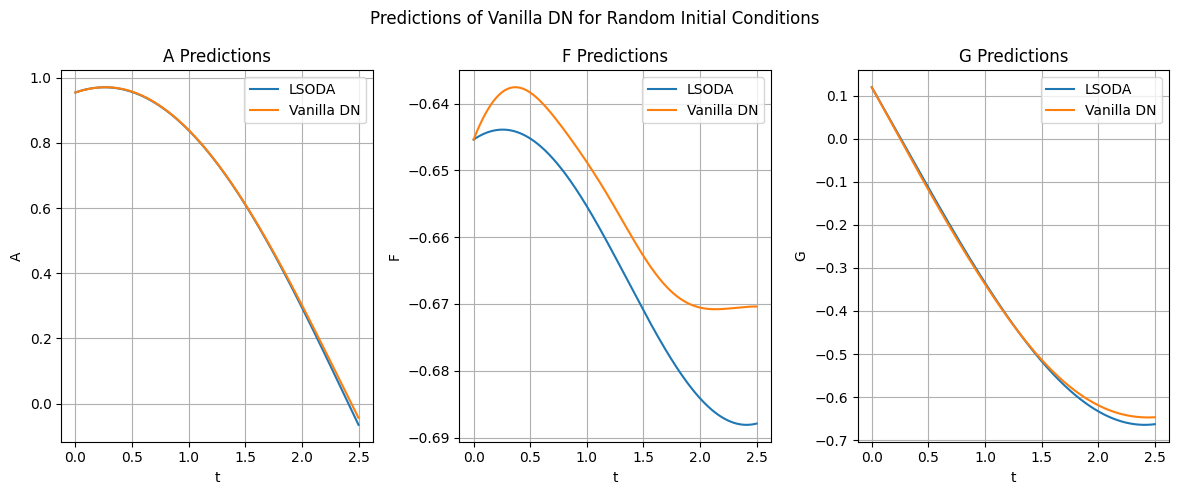

In [53]:
fig = plt.figure(figsize=(12, 5))
fig.suptitle('Predictions of Vanilla DN for Random Initial Conditions')


plt.subplot(1, 3, 1)
plt.tight_layout()
plt.plot(t, A_rk)
plt.plot(t, A_nocons)
plt.xlabel("t")
plt.ylabel("A")
plt.grid()
plt.legend(['LSODA', 'Vanilla DN'])
plt.title("A Predictions")

plt.subplot(1, 3, 2)
plt.tight_layout()
plt.plot(t, F_rk)
plt.plot(t, F_nocons)
plt.xlabel("t")
plt.ylabel("F")
plt.grid()
plt.legend(['LSODA', 'Vanilla DN'])
plt.title("F Predictions")


plt.subplot(1, 3, 3)
plt.tight_layout()
plt.plot(t, G_rk)
plt.plot(t, G_nocons)
plt.xlabel("t")
plt.ylabel("G")
plt.grid()
plt.legend(['LSODA', 'Vanilla DN'])
plt.title("G Predictions")


plt.show()
#fig.savefig('L1960_vanilla_preds_5000ep.png')

<>:13: SyntaxWarning: invalid escape sequence '\o'
<>:13: SyntaxWarning: invalid escape sequence '\ '
<>:24: SyntaxWarning: invalid escape sequence '\o'
<>:24: SyntaxWarning: invalid escape sequence '\ '
<>:36: SyntaxWarning: invalid escape sequence '\o'
<>:36: SyntaxWarning: invalid escape sequence '\ '
<>:13: SyntaxWarning: invalid escape sequence '\o'
<>:13: SyntaxWarning: invalid escape sequence '\ '
<>:24: SyntaxWarning: invalid escape sequence '\o'
<>:24: SyntaxWarning: invalid escape sequence '\ '
<>:36: SyntaxWarning: invalid escape sequence '\o'
<>:36: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_1076/1863013086.py:13: SyntaxWarning: invalid escape sequence '\o'
  plt.legend(['LSODA', 'w\o Conservative Constraints', 'w\ Conservative Constraints'])
/tmp/ipykernel_1076/1863013086.py:13: SyntaxWarning: invalid escape sequence '\ '
  plt.legend(['LSODA', 'w\o Conservative Constraints', 'w\ Conservative Constraints'])
/tmp/ipykernel_1076/1863013086.py:24: SyntaxWarnin

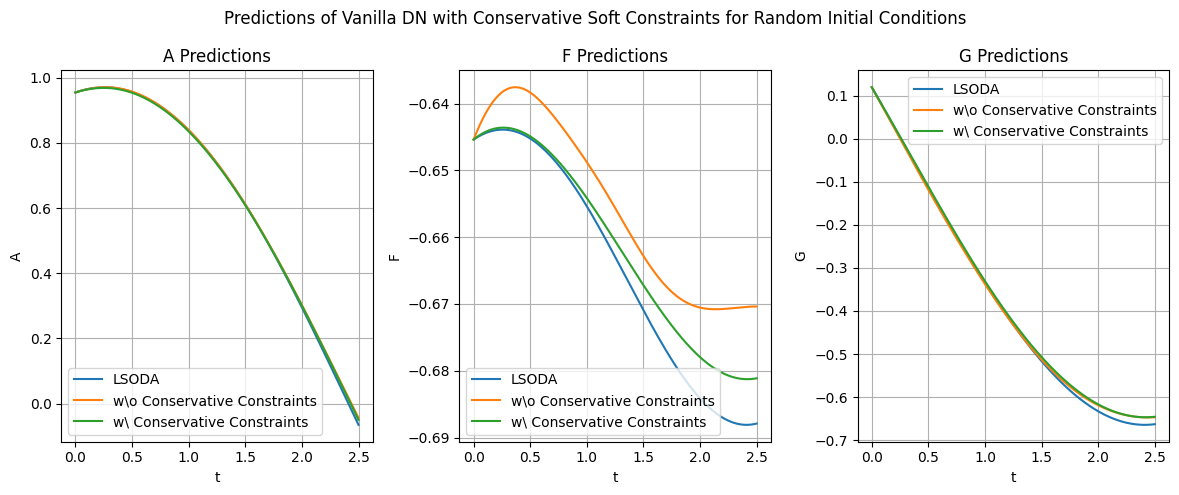

In [54]:
fig = plt.figure(figsize=(12, 5))
fig.suptitle('Predictions of Vanilla DN with Conservative Soft Constraints for Random Initial Conditions')


plt.subplot(1, 3, 1)
plt.tight_layout()
plt.plot(t, A_rk)
plt.plot(t, A_nocons)
plt.plot(t, A_cons)
plt.xlabel("t")
plt.ylabel("A")
plt.grid()
plt.legend(['LSODA', 'w\o Conservative Constraints', 'w\ Conservative Constraints'])
plt.title("A Predictions")

plt.subplot(1, 3, 2)
plt.tight_layout()
plt.plot(t, F_rk)
plt.plot(t, F_nocons)
plt.plot(t, F_cons)
plt.xlabel("t")
plt.ylabel("F")
plt.grid()
plt.legend(['LSODA', 'w\o Conservative Constraints', 'w\ Conservative Constraints'])
plt.title("F Predictions")


plt.subplot(1, 3, 3)
plt.tight_layout()
plt.plot(t, G_rk)
plt.plot(t, G_nocons)
plt.plot(t, G_cons)
plt.xlabel("t")
plt.ylabel("G")
plt.grid()
plt.legend(['LSODA', 'w\o Conservative Constraints', 'w\ Conservative Constraints'])
plt.title("G Predictions")


plt.show()
#fig.savefig('L1960_vanilla_consconstraints_preds_5000ep.png')

In [38]:
@jax.jit
def f_func(args, EV_0) :

    args = jnp.reshape(args, (-1,))
    EV_0 = jnp.reshape(EV_0, (-1,))

    A, F, G = args[0], args[1], args[2]
    E_0, V_0 = EV_0[0], EV_0[1]

    E, V = calc_EV(A, F, G)

    f_val = (E - E_0)**2 + (V - V_0)**2

    f = jnp.array([[f_val]])
    

    return f


@jax.jit
def gradf_func(args, EV_0) :

    args = jnp.reshape(args, (-1,))
    EV_0 = jnp.reshape(EV_0, (-1,))

    A, F, G = args[0], args[1], args[2]
    E_0, V_0 = EV_0[0], EV_0[1]
    
    dE_dA = A/(2*(l**2))
    dE_dF = F/(2*(k**2))
    dE_dG = G/(k**2 + l**2)

    dV_dA = A
    dV_dF = F
    dV_dG = 2*G

    E, V = calc_EV(A, F, G)

    df_dA = 2*(E-E_0)*dE_dA + 2*(V-V_0)*dV_dA
    df_dF = 2*(E-E_0)*dE_dF + 2*(V-V_0)*dV_dF
    df_dG = 2*(E-E_0)*dE_dG + 2*(V-V_0)*dV_dG

    grad_f = jnp.array([[df_dA], [df_dF], [df_dG]])

    return grad_f


@jax.jit
def find_rec(x):
    
    x = x + jnp.finfo(jnp.float64).eps
    
    return 1/x


@jax.jit
def wolfe_conds(args):

    alpha, curr_x, curr_f, curr_grad, next_x, next_f, next_grad, p, EV_0, iter = args

    c1 = 1e-4

    cond = next_f - curr_f - c1*alpha*(curr_grad.T@p)

    cond_bool = jax.lax.cond(cond[0][0] > 0.0 , lambda x: True, lambda x: False, None)
    final_bool = cond_bool
    
    return final_bool


@jax.jit
def update_alpha(args) :

    alpha, curr_x, curr_f, curr_grad, next_x, next_f, next_grad, p, EV_0, iter = args

    alpha = alpha*0.1
    iter = iter + 1
        
    next_x = curr_x + alpha*p
    next_f = f_func(next_x, EV_0)
    next_grad = gradf_func(next_x, EV_0) 
   
    return (alpha, curr_x, curr_f, curr_grad, next_x, next_f, next_grad, p, EV_0, iter)


@jax.jit
def BFGS(x, EV_0) :

    iter_num = 0
    init_iter = 0
    alpha = 1.0
    I_3 = jnp.identity(3, dtype = jnp.float64)
    B_0_inv = jnp.identity(3, dtype = jnp.float64)

    x_0 = x
    x_0 = jnp.reshape(x_0, (-1, 1))

    D_0 = f_func(x_0, EV_0)
    gradD_0 = gradf_func(x_0, EV_0)

    p = -(B_0_inv@gradD_0)

    pot_x = x_0 + alpha*p
    pot_D = f_func(pot_x, EV_0)
    pot_gradD = gradf_func(pot_x, EV_0)

    init_args = (alpha, x_0, D_0, gradD_0, pot_x, pot_D, pot_gradD, p, EV_0, init_iter)
    
    step, _, _, _, _, _, _, _, _, _ = jax.lax.while_loop(wolfe_conds, update_alpha, init_args)

    x_1 = x_0 + step*p

    while iter_num < 10:

        delta_x = x_1 - x_0

        D_1 = f_func(x_1, EV_0)
        gradD_1 = gradf_func(x_1, EV_0)

        y = gradD_1 - gradD_0       

        y_T_delta_x = y.T@delta_x
        y_T_delta_x_rec = find_rec(y_T_delta_x)
        
        B_1_inv = ((I_3 - (y_T_delta_x_rec*(delta_x@y.T)))@B_0_inv@(I_3 - (y_T_delta_x_rec*(y@delta_x.T)))) + (y_T_delta_x_rec*(delta_x@delta_x.T))   
        p = -(B_1_inv@gradD_1)
        
        pot_x = x_1 + alpha*p
        pot_D = f_func(pot_x, EV_0)
        pot_gradD = gradf_func(pot_x, EV_0) 
                  
        init_args = (alpha, x_1, D_1, gradD_1, pot_x, pot_D, pot_gradD, p, EV_0, init_iter)

        step, _, _, _, _, _, _, _, _, _ = jax.lax.while_loop(wolfe_conds, update_alpha, init_args)

        x_temp = x_1 + step*p

        x_0 = x_1
        x_1 = x_temp

        D_0 = D_1
        gradD_0 = gradD_1

        B_0_inv = B_1_inv
        
        iter_num = iter_num + 1

    A = x_1[0]
    F = x_1[1]
    G = x_1[2]

    A = jnp.reshape(A, (-1, ))[0]
    F = jnp.reshape(F, (-1, ))[0]
    G = jnp.reshape(G, (-1, ))[0]


    return x_1

@jax.jit
def find_min_bfgs(x, EV_0) :


    return jnp.squeeze(jax.vmap(BFGS, (0, 0), 0)(x, EV_0))

In [39]:
x_test = jnp.array([[1.0, 2.0, 3.0], [1.0, 2.0, 3.0]])
EV_test = jnp.array([[4.0, 5.0], [4.0, 5.0]])

test = find_min_bfgs(x_test, EV_test)
print(test.shape, test)

(2, 3) [[-0.0510694   3.34916765  0.09440251]
 [-0.0510694   3.34916765  0.09440251]]


In [40]:
n = 500

t = np.linspace(t0, tfinal, n)

A_data = np.random.uniform(-1.0, 1.0, size=(1,))
F_data = np.random.uniform(-1.0, 1.0, size=(1,))
G_data = np.random.uniform(-1.0, 1.0, size=(1,))

E_data, V_data = calc_EV(A_data, F_data, G_data)

E_data = np.repeat(np.expand_dims(E_data, axis=0), n, axis=0)
V_data = np.repeat(np.expand_dims(V_data, axis=0), n, axis=0)

tEV = np.column_stack([t, E_data, V_data])
init_data = np.column_stack([A_data, F_data, G_data])

init_data = np.reshape(init_data, (-1,))

z_init = np.repeat(np.expand_dims(init_data, axis=0), n, axis=0)

print(tEV.shape, z_init.shape)


sol_rk = odeint(Lorenz1960, init_data, t, rtol = 1e-13, atol = 1e-13)
A_rk, F_rk, G_rk = sol_rk[:,0], sol_rk[:,1], sol_rk[:,2]
E_rk, V_rk = calc_EV(A_rk, F_rk, G_rk)


A = jax.vmap(var_model, [0, 0, None, None])(tEV, z_init, 0, params)
F = jax.vmap(var_model, [0, 0, None, None])(tEV, z_init, 1, params)
G = jax.vmap(var_model, [0, 0, None, None])(tEV, z_init, 2, params)
E, V = calc_EV(A, F, G)

args_arr = jnp.column_stack([A, F, G])
EV_arr = tEV[:, 1:]

xbfgs = find_min_bfgs(args_arr, EV_arr)
A_bfgs, F_bfgs, G_bfgs = xbfgs[:, 0], xbfgs[:, 1], xbfgs[:, 2]
E_bfgs, V_bfgs = calc_EV(A_bfgs, F_bfgs, G_bfgs)

(500, 3) (500, 3)


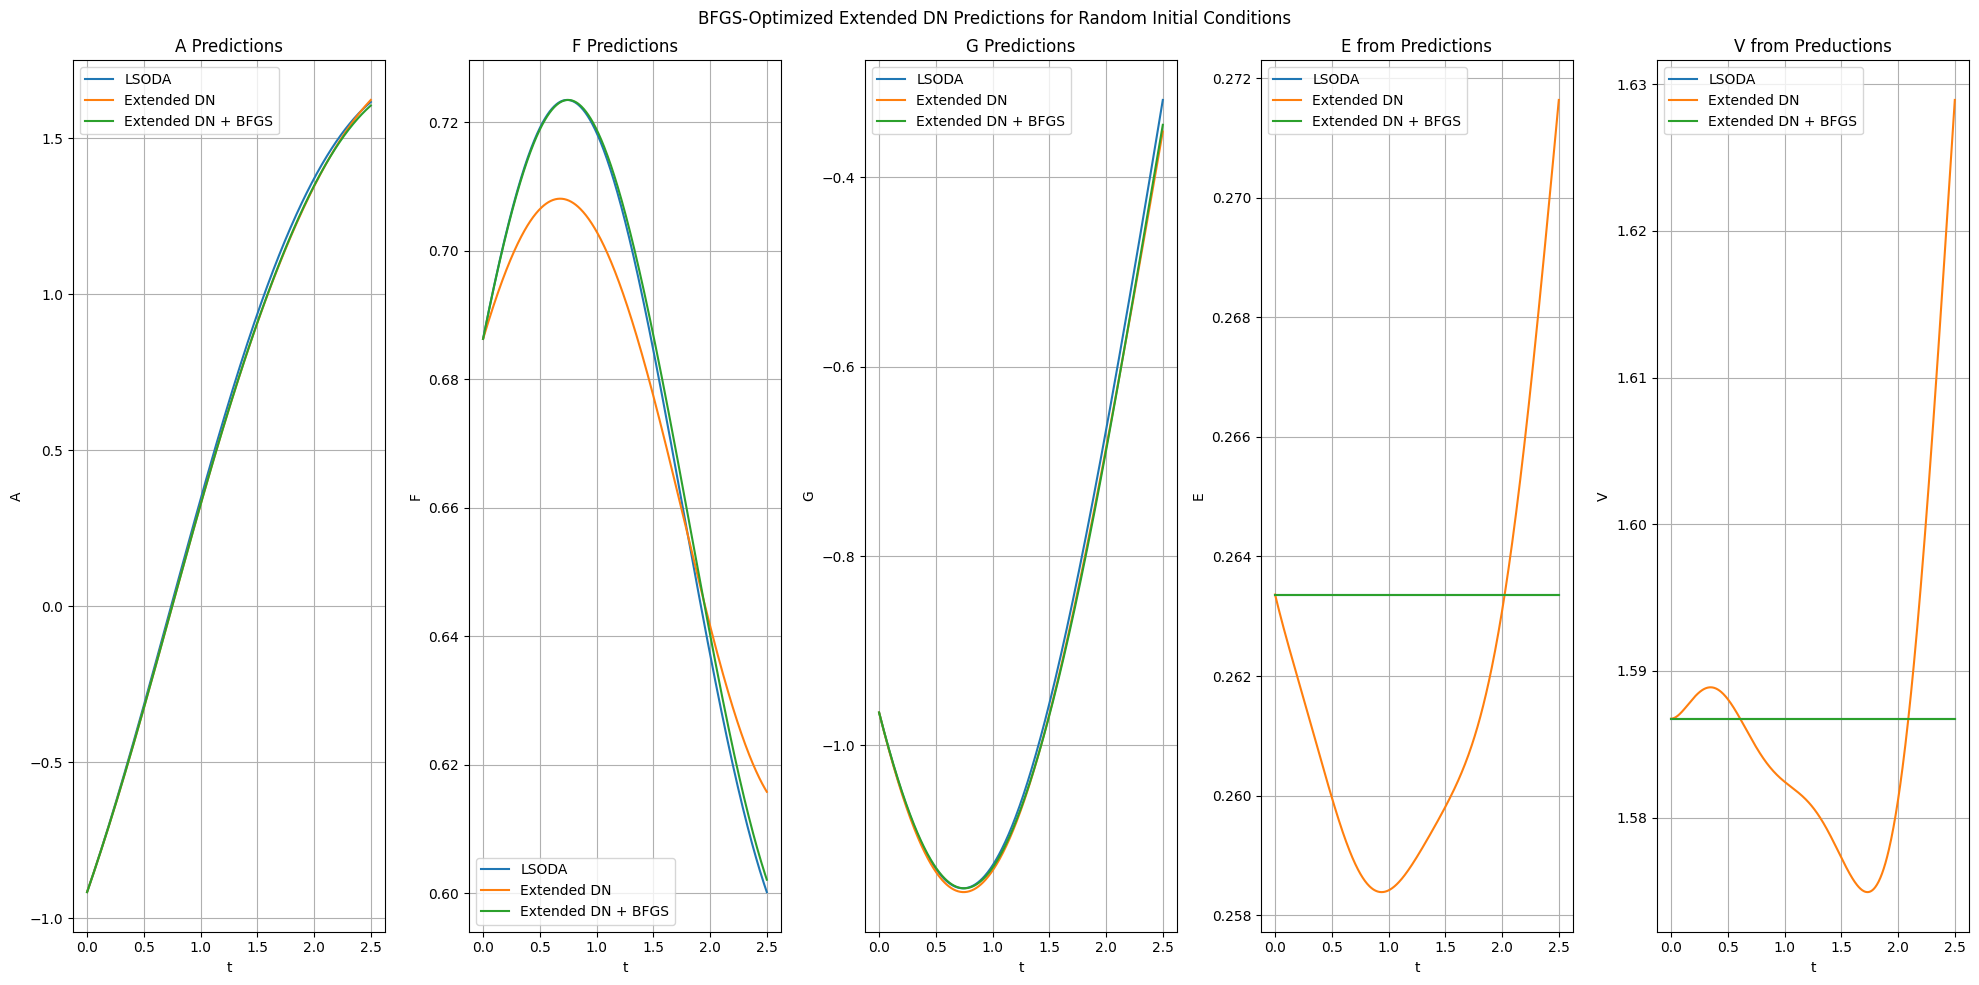

In [41]:
fig = plt.figure(figsize=(20, 10))
fig.suptitle('BFGS-Optimized Extended DN Predictions for Random Initial Conditions')


plt.subplot(1, 5, 1)
plt.tight_layout()
plt.plot(t, A_rk)
plt.plot(t, A)
plt.plot(t, A_bfgs)
plt.xlabel("t")
plt.ylabel("A")
plt.grid()
plt.legend(['LSODA', 'Extended DN', 'Extended DN + BFGS'])
plt.title("A Predictions")

plt.subplot(1, 5, 2)
plt.tight_layout()
plt.plot(t, F_rk)
plt.plot(t, F)
plt.plot(t, F_bfgs)
plt.xlabel("t")
plt.ylabel("F")
plt.grid()
plt.legend(['LSODA', 'Extended DN', 'Extended DN + BFGS'])
plt.title("F Predictions")


plt.subplot(1, 5, 3)
plt.tight_layout()
plt.plot(t, G_rk)
plt.plot(t, G)
plt.plot(t, G_bfgs)
plt.xlabel("t")
plt.ylabel("G")
plt.grid()
plt.legend(['LSODA', 'Extended DN', 'Extended DN + BFGS'])
plt.title("G Predictions")

         
plt.subplot(1, 5, 4)
plt.tight_layout()
plt.plot(t, E_rk)
plt.plot(t, E)
plt.plot(t, E_bfgs)
plt.xlabel("t")
plt.ylabel("E")
plt.grid()
plt.legend(['LSODA', 'Extended DN', 'Extended DN + BFGS'])
plt.title("E from Predictions")


plt.subplot(1, 5, 5)
plt.tight_layout()
plt.plot(t, V_rk)
plt.plot(t, V)
plt.plot(t, V_bfgs)
plt.xlabel("t")
plt.ylabel("V")
plt.grid()
plt.legend(['LSODA', 'Extended DN', 'Extended DN + BFGS'])
plt.title("V from Preductions")


plt.show()
#fig.savefig('L1960_extended_+_bfgs_preds_5000ep.png')

In [223]:
class ClosestPoint(nn.Module):

    EV_0: float
    
    @nn.compact
    def __call__(self, inputs):
    
        z_min = find_min_bfgs(inputs, self.EV_0)
    
        return z_min

In [224]:
class CDeepONet(nn.Module):

  t0: float
  tfinal: float
  Emin: float
  Emax: float
  Vmin: float
  Vmax: float
  layers: int
  units: int

  @nn.compact
  def __call__(self, t, u):

    if u.ndim == 1:
      u = jnp.reshape(u, (1,-1))
      
    if t.ndim == 1:
      t = jnp.reshape(t, (1,-1))
        
    t_0 = t[:, :1]
    E_0 = t[:, 1:2]
    V_0 = t[:, 2:3]
      
    t_0 = jnp.reshape(t_0, (-1,1))
    t_0_norm = Normalize(self.t0, self.tfinal)(t_0)

    E_0_norm = Normalize(self.Emin, self.Emax)(E_0)  
    V_0_norm = Normalize(self.Vmin, self.Vmax)(V_0)

    b = jnp.column_stack((t_0_norm, E_0_norm, V_0_norm))
    # b = t_0_norm
      
    A_0 = u[:,:1]
    F_0 = u[:,1:2]
    G_0 = u[:,2:3]

    trunk_net = MLP(self.layers, self.units)(b)
    branch_net = MLP(self.layers, self.units)(u)

    A_tr = trunk_net[:,:self.units]
    F_tr = trunk_net[:,self.units:2*self.units]
    G_tr = trunk_net[:,2*self.units:]

    A_br = branch_net[:,:self.units]
    F_br = branch_net[:,self.units:2*self.units]
    G_br = branch_net[:,2*self.units:]

    A = CombineBranches()(A_tr, A_br)
    F = CombineBranches()(F_tr, F_br)
    G = CombineBranches()(G_tr, G_br)

    A = HardConstraint(self.t0, self.tfinal, A_0)([t_0, A])
    F = HardConstraint(self.t0, self.tfinal, F_0)([t_0, F])
    G = HardConstraint(self.t0, self.tfinal, G_0)([t_0, G])

    z = jnp.column_stack([A, F, G])
    EV_0 = jnp.column_stack([E_0, V_0])
      
    z = ClosestPoint(EV_0)(z)
    z = jnp.reshape(z, (-1, 3))

    A = z[:, :1]
    F = z[:, 1:2]
    G = z[:, 2:3]

    A = jnp.reshape(A, (-1,))
    F = jnp.reshape(F, (-1,))
    G = jnp.reshape(G, (-1,))
    E = (0.25)*((A**2/l**2) + (F**2/k**2) + (2.*(G**2)/(k**2 + l**2)))
    V = (0.5)*(A**2 + F**2 + 2.*(G**2))


    return A, F, G, E, V

In [231]:
@partial(jax.jit, static_argnums=(2,))
def Cvar_model(t, z, component, params):
  return Cdeeponet.apply(params, t, z)[component][0]

@partial(jax.jit, static_argnums=(2,))
def Cvar(t, z, component, params):
  return jax.vmap(Cvar_model, [0, 0, None, None])(t, z, component, params)

@partial(jax.jit, static_argnums=(2,))
def Cvar_t(t, z, component, params):
  return jax.vmap(jax.grad(Cvar_model, 0), [0, 0, None, None])(t, z, component, params)

@jax.jit
def Closs(params, tEV, z):

    A_t_loss_w = 1.0
    F_t_loss_w = 1.0
    G_t_loss_w = 1.0
    
    diff_loss_w = 1.0
    E_loss_w = 1.0
    V_loss_w = 1.0
    
    E_0_val = tEV[:, -2]
    V_0_val = tEV[:, -1]
    
    A_val = Cvar(tEV, z, 0, params)
    F_val = Cvar(tEV, z, 1, params)
    G_val = Cvar(tEV, z, 2, params)
    E_val = Cvar(tEV, z, 3, params)
    
    dA = Cvar_t(tEV, z, 0, params)
    A_t_val = dA[:, 0]
    
    dF = Cvar_t(tEV, z, 1, params)
    F_t_val = dF[:, 0]
    
    dG = Cvar_t(tEV, z, 2, params)
    G_t_val = dG[:, 0]

    dE = Cvar_t(tEV, z, 3, params)
    E_t_val = dE[:, 0]
    E_t_loss = jnp.square(E_t_val)
    E_t_loss = jnp.mean(E_t_loss)
    
    dV = Cvar_t(tEV, z, 4, params)
    V_t_val = dV[:, 0]
    V_t_loss = jnp.square(V_t_val)
    V_t_loss = jnp.mean(V_t_loss)

    dA_dE = dA[:, 1]
    dA_dV = dA[:, 2]

    dF_dE = dF[:, 1]
    dF_dV = dF[:, 2]
    
    dG_dE = dG[:, 1]
    dG_dV = dG[:, 2]

    dE_dE = dE[:, 1]
    E_E_loss = dE_dE - 1.0
    E_E_loss = jnp.square(E_E_loss)
    E_E_loss = jnp.mean(E_E_loss)

    E_val = (0.25)*((A_val**2/l**2) + (F_val**2/k**2) + (2.*(G_val**2)/(k**2 + l**2)))
    E_loss = E_val - E_0_val
    E_loss = jnp.square(E_loss)
    E_loss = jnp.mean(E_loss)
    
    V_val = (0.5)*(A_val**2 + F_val**2 + 2.*(G_val**2))
    V_loss = V_val - V_0_val
    V_loss = jnp.square(V_loss)
    V_loss = jnp.mean(V_loss)
        
    A_t_loss = A_t_val + (1./(k**2) - 1./(k**2 + l**2))*(k * l * F_val * G_val)
    A_t_loss = jnp.square(A_t_loss)
    A_t_loss = jnp.mean(A_t_loss)
    
    F_t_loss = F_t_val - (1./(l**2) - 1./(k**2 + l**2))*(k * l * A_val * G_val)
    F_t_loss = jnp.square(F_t_loss)
    F_t_loss = jnp.mean(F_t_loss)
    
    G_t_loss = G_t_val + (0.5)*(1./(l**2) - 1./(k**2))*(k * l * A_val * F_val)
    G_t_loss = jnp.square(G_t_loss)
    G_t_loss = jnp.mean(G_t_loss)
    
    diff_loss = A_t_loss_w*A_t_loss + F_t_loss_w*F_t_loss + G_t_loss_w*G_t_loss
    
    final_loss = diff_loss_w*diff_loss + E_loss_w*E_loss + V_loss_w*V_loss
    
    return final_loss

@jax.jit
def Ctrain_step(params, pdes, z):
    tEV = pdes
    
    return jax.value_and_grad(Closs)(params, tEV, z)


@partial(jax.jit, static_argnums=(3,))
def Coptimize(grads, opt_state, params, optimizer_update):
    updates, opt_state = optimizer_update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state

In [232]:
def Ctrain_network(params, des, sensors, epochs=100):

    N = de_points.shape[0]
    
    nr_batches = 10
    batch_size = len(des)//nr_batches
    
    print("batch size:", batch_size)
    
    lr = 1e-6
    optimizer = optax.adam(lr)
    opt_state = optimizer.init(params)
    
    ds_z = tf.data.Dataset.from_tensor_slices(sensors)
    ds_de = tf.data.Dataset.from_tensor_slices(des)
    
    ds = tf.data.Dataset.zip((ds_de, ds_z))
    ds = ds.shuffle(N).batch(batch_size)
    
    epoch_loss = np.zeros(epochs)
    
    for i in range(epochs):

        batch_no = 0
    
        for (des_batch, z_batch) in ds:
    
            loss, grads = Ctrain_step(params, des_batch.numpy(), z_batch.numpy())
            
            params, opt_state = Coptimize(grads, opt_state, params, optimizer.update)
            
            epoch_loss[i] += loss

            batch_no = batch_no + 1

        epoch_loss[i] /= batch_size

        if i % 1  == 0:
            print(f'Loss in epoch {i}: {epoch_loss[i]}')

    return params, epoch_loss

In [233]:
Cdeeponet = CDeepONet(t0, tfinal, Emin, Emax, Vmin, Vmax, layers=4, units=40)

t_init = jnp.full((10, 3), 1.0, dtype = jnp.float64)
u_init = jnp.full((10, 3), 1.0, dtype = jnp.float64 )

Cparams = Cdeeponet.init(jax.random.PRNGKey(0), t_init, u_init)

In [234]:
Cparam_count = sum(x.size for x in jax.tree.leaves(Cparams))
print(Cparam_count)

16720


In [235]:
Cparams = copy.deepcopy(params)

In [236]:
epochs = 1000
Cparams, Closs = Ctrain_network(Cparams, de_points, zsensors, epochs)

batch size: 100
Loss in epoch 0: 8.434935094460505e-06
Loss in epoch 1: 8.147117822964159e-06
Loss in epoch 2: 7.916973200544332e-06
Loss in epoch 3: 7.717844706852062e-06
Loss in epoch 4: 7.5547336819466054e-06
Loss in epoch 5: 7.386311651218609e-06
Loss in epoch 6: 7.213599134005941e-06
Loss in epoch 7: 7.080722948042185e-06
Loss in epoch 8: 6.921648494954249e-06
Loss in epoch 9: 6.79967395505268e-06
Loss in epoch 10: 6.666944939223633e-06
Loss in epoch 11: 6.55012562826019e-06
Loss in epoch 12: 6.435860787033208e-06
Loss in epoch 13: 6.326113981711592e-06
Loss in epoch 14: 6.217731990966284e-06
Loss in epoch 15: 6.118069082722504e-06
Loss in epoch 16: 6.038197696209506e-06
Loss in epoch 17: 5.94938947351898e-06
Loss in epoch 18: 5.8807100900394966e-06
Loss in epoch 19: 5.800540471360697e-06
Loss in epoch 20: 5.745500173730511e-06
Loss in epoch 21: 5.686164902726377e-06
Loss in epoch 22: 5.6669600109944714e-06
Loss in epoch 23: 5.62674621506172e-06
Loss in epoch 24: 5.579618265005794

(4000,)


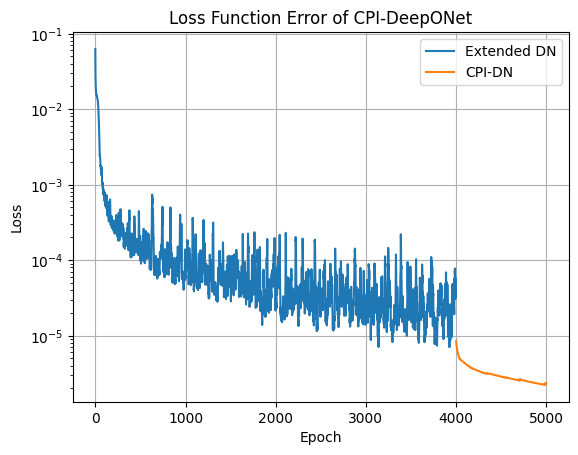

In [240]:
split = 4000
num_ep = [i for i in range(0, split)]
Cnum_ep = [i for i in range(split, 5000)]

print(loss.shape)

plt.semilogy(num_ep, loss)
plt.semilogy(Cnum_ep, Closs)
plt.legend(["Extended DN", "CPI-DN"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Function Error of CPI-DeepONet")
plt.grid()
# plt.savefig('L1960_cpi_loss_4000+1000ep.png')

In [237]:
# tree_info, shapes, Cparams_flat = flatten_pytree(Cparams)
# jnp.save("last_one_ahhhh", Cparams_flat)

# Cparams_flat = jnp.load("L1960_t2.5_4500+500BFGS_ep_Cparams.npy")
# Cparams = reconstruct_pytree(tree_info, shapes, Cparams_flat)

In [57]:
n = 500

t = np.linspace(t0, tfinal, n)

A_data = np.random.uniform(-1.0, 1.0, size=(1,))
F_data = np.random.uniform(-1.0, 1.0, size=(1,))
G_data = np.random.uniform(-1.0, 1.0, size=(1,))

E_data, V_data = calc_EV(A_data, F_data, G_data)

E_data = np.repeat(np.expand_dims(E_data, axis=0), n, axis=0)
V_data = np.repeat(np.expand_dims(V_data, axis=0), n, axis=0)

tEV = np.column_stack([t, E_data, V_data])
init_data = np.column_stack([A_data, F_data, G_data])

init_data = np.reshape(init_data, (-1,))

z_init = np.repeat(np.expand_dims(init_data, axis=0), n, axis=0)

print(tEV.shape, z_init.shape)


sol_rk = odeint(Lorenz1960, init_data, t, rtol = 1e-13, atol = 1e-13)
A_rk, F_rk, G_rk = sol_rk[:,0], sol_rk[:,1], sol_rk[:,2]
E_rk, V_rk = calc_EV(A_rk, F_rk, G_rk)


A = jax.vmap(var_model, [0, 0, None, None])(tEV, z_init, 0, params)
F = jax.vmap(var_model, [0, 0, None, None])(tEV, z_init, 1, params)
G = jax.vmap(var_model, [0, 0, None, None])(tEV, z_init, 2, params)
E, V = calc_EV(A, F, G)

args_arr = jnp.column_stack([A, F, G])
EV_arr = tEV[:, 1:]

xbfgs = find_min_bfgs(args_arr, EV_arr)
A_bfgs, F_bfgs, G_bfgs = xbfgs[:, 0], xbfgs[:, 1], xbfgs[:, 2]
E_bfgs, V_bfgs = calc_EV(A_bfgs, F_bfgs, G_bfgs)


CA = jax.vmap(Cvar_model, [0, 0, None, None])(tEV, z_init, 0, Cparams)
CF = jax.vmap(Cvar_model, [0, 0, None, None])(tEV, z_init, 1, Cparams)
CG = jax.vmap(Cvar_model, [0, 0, None, None])(tEV, z_init, 2, Cparams)
CE, CV = calc_EV(CA, CF, CG)

(500, 3) (500, 3)


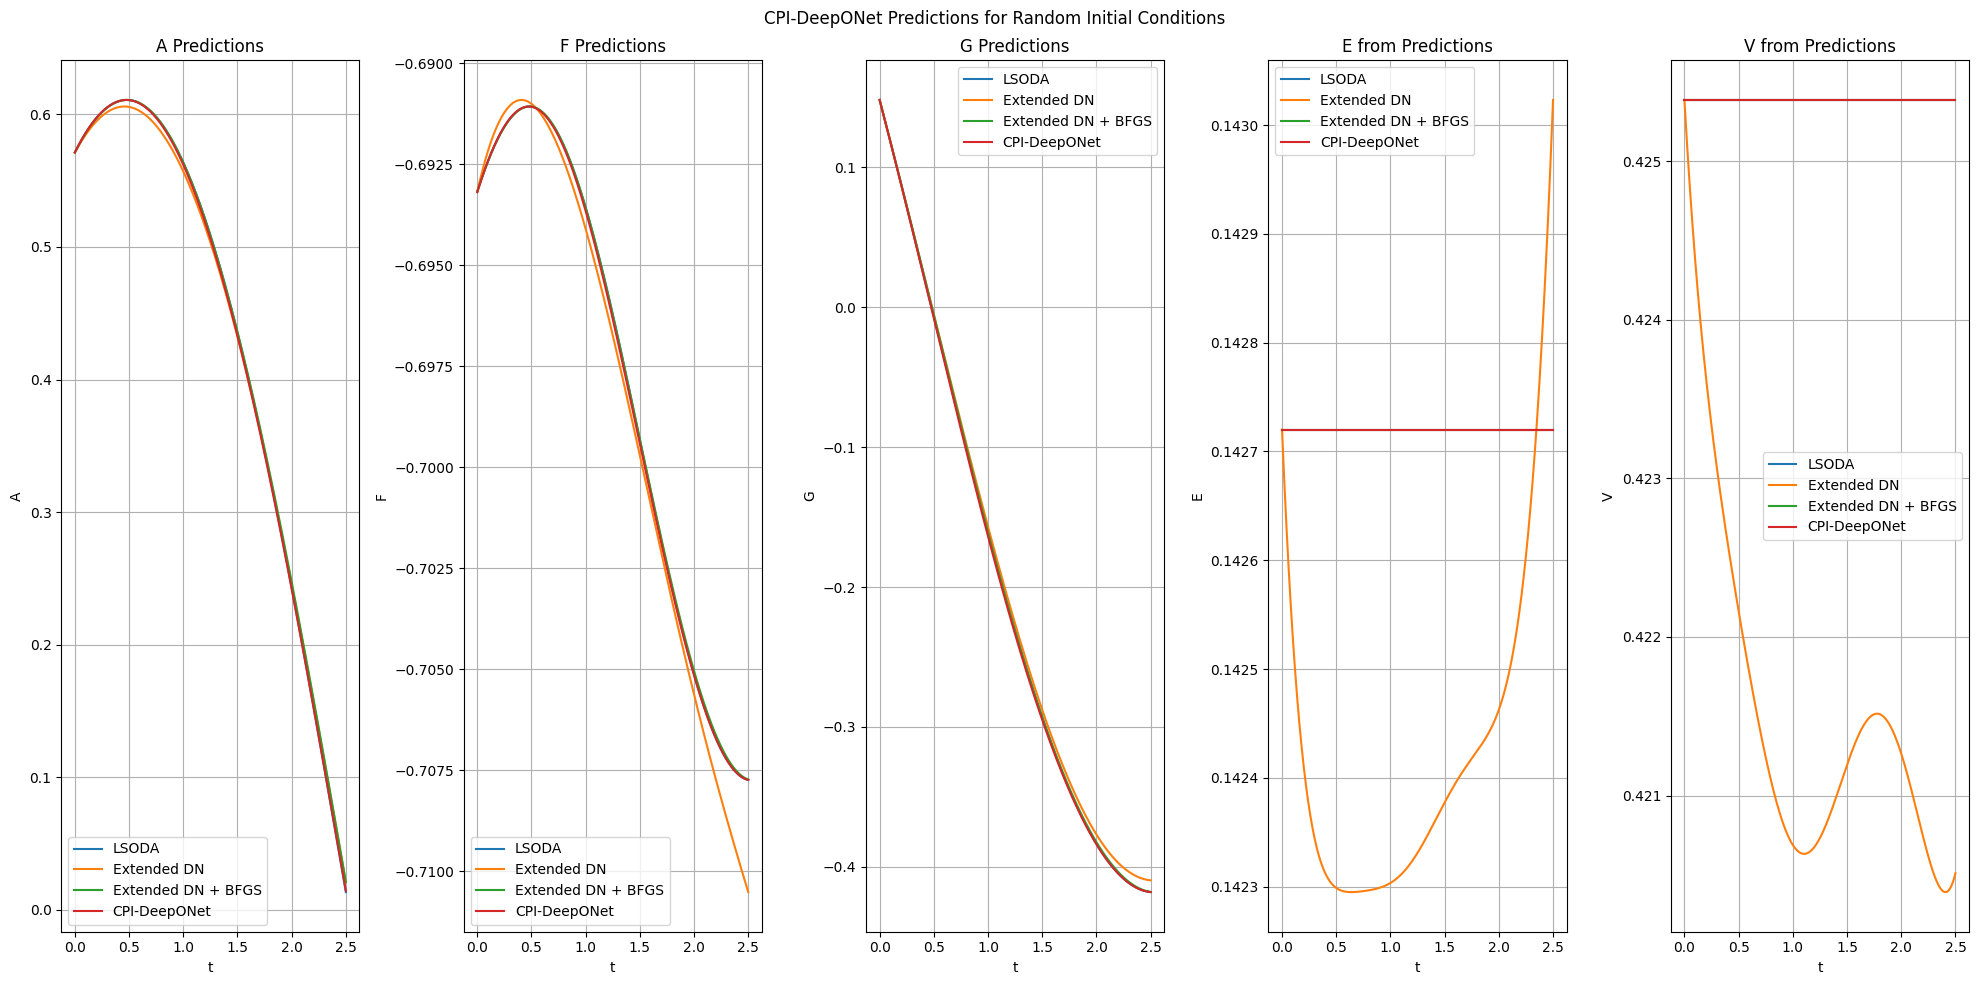

In [58]:
fig = plt.figure(figsize=(20, 10))
fig.suptitle('CPI-DeepONet Predictions for Random Initial Conditions')


plt.subplot(1, 5, 1)
plt.tight_layout()
plt.plot(t, A_rk)
plt.plot(t, A)
plt.plot(t, A_bfgs)
plt.plot(t, CA)
plt.xlabel("t")
plt.ylabel("A")
plt.grid()
plt.legend(['LSODA', 'Extended DN', 'Extended DN + BFGS', 'CPI-DeepONet'])
plt.title("A Predictions")

plt.subplot(1, 5, 2)
plt.tight_layout()
plt.plot(t, F_rk)
plt.plot(t, F)
plt.plot(t, F_bfgs)
plt.plot(t, CF)
plt.xlabel("t")
plt.ylabel("F")
plt.grid()
plt.legend(['LSODA', 'Extended DN', 'Extended DN + BFGS', 'CPI-DeepONet'])
plt.title("F Predictions")


plt.subplot(1, 5, 3)
plt.tight_layout()
plt.plot(t, G_rk)
plt.plot(t, G)
plt.plot(t, G_bfgs)
plt.plot(t, CG)
plt.xlabel("t")
plt.ylabel("G")
plt.grid()
plt.legend(['LSODA', 'Extended DN', 'Extended DN + BFGS', 'CPI-DeepONet'])
plt.title("G Predictions")

         
plt.subplot(1, 5, 4)
plt.tight_layout()
plt.plot(t, E_rk)
plt.plot(t, E)
plt.plot(t, E_bfgs)
plt.plot(t, CE)
plt.xlabel("t")
plt.ylabel("E")
plt.grid()
plt.legend(['LSODA', 'Extended DN', 'Extended DN + BFGS', 'CPI-DeepONet'])
plt.title("E from Predictions")


plt.subplot(1, 5, 5)
plt.tight_layout()
plt.plot(t, V_rk)
plt.plot(t, V)
plt.plot(t, V_bfgs)
plt.plot(t, CV)
plt.xlabel("t")
plt.ylabel("V")
plt.grid()
plt.legend(['LSODA', 'Extended DN', 'Extended DN + BFGS', 'CPI-DeepONet'])
plt.title("V from Predictions")

plt.show()
#fig.savefig('L1960_extended_+_bfgs_+_CPI_preds_5000ep.png')

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49


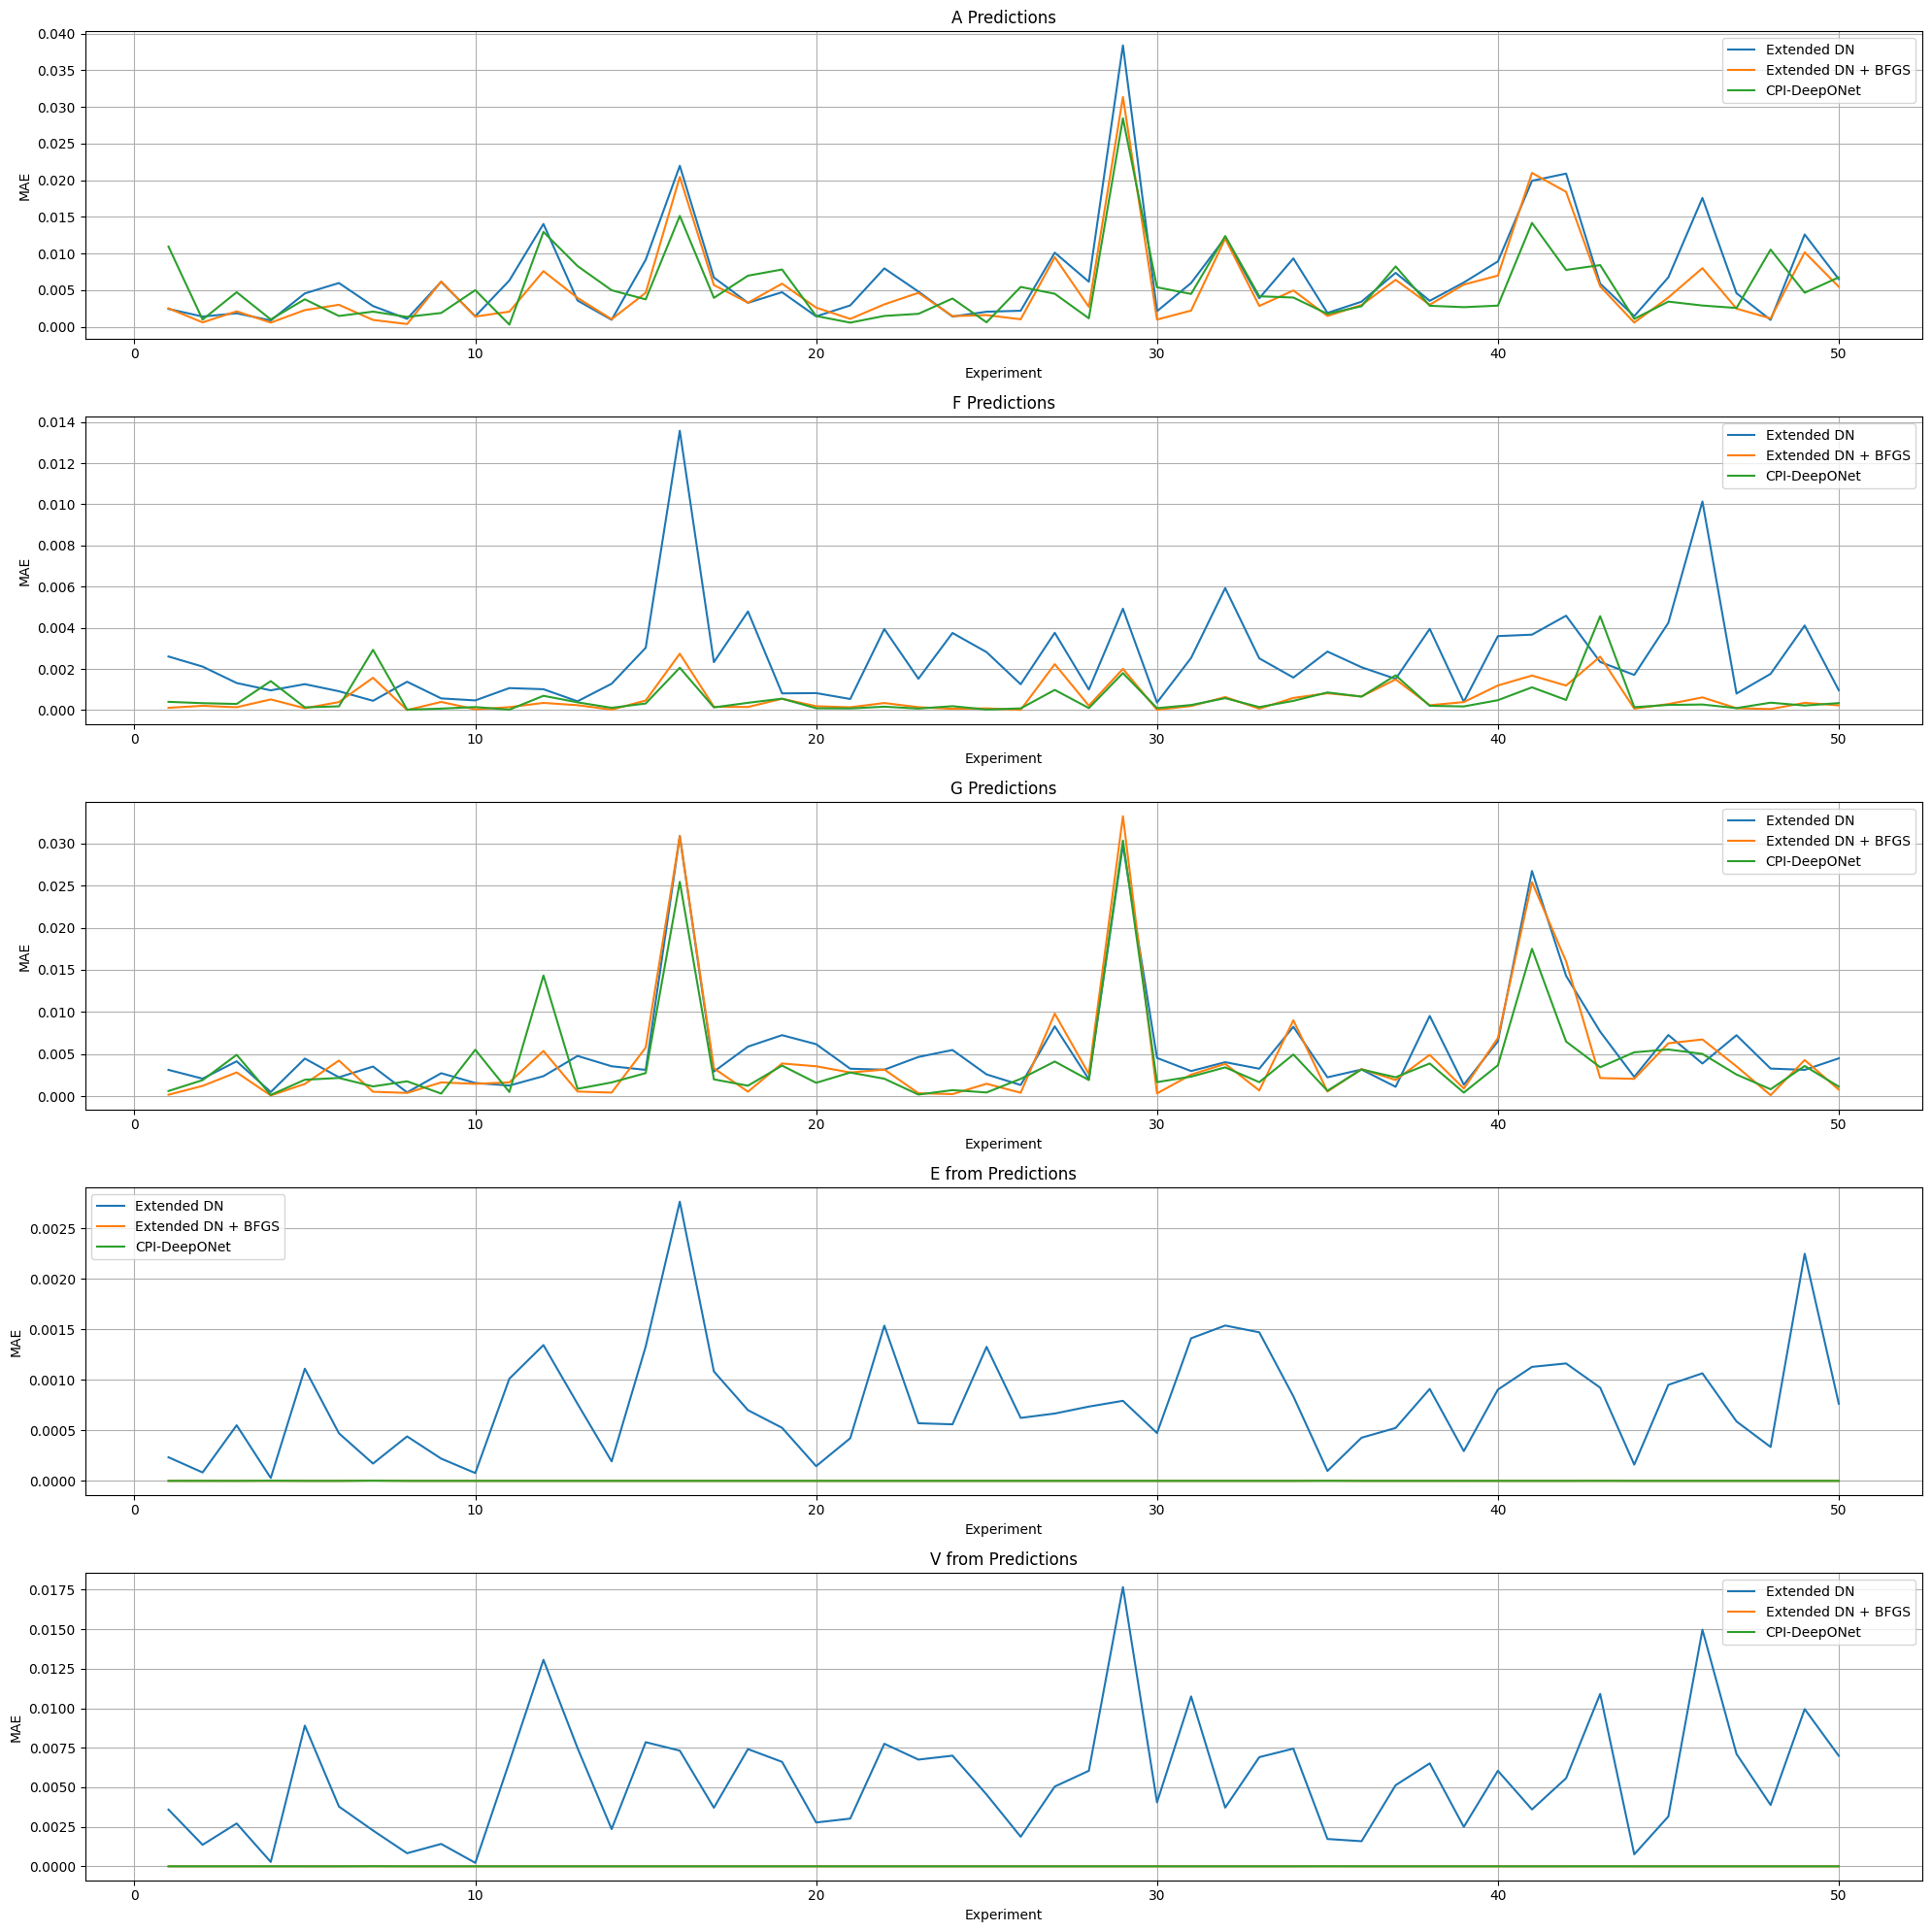

In [59]:
def run_test(num_vars, num_models, num_exp, models_lst, params_lst, labels_lst, bfgs_lst) :

    n = 500
    t = np.linspace(t0, tfinal, n)
    
    
    preds = np.zeros((num_exp, num_models, num_vars, n))
    preds_error = np.zeros((num_exp, num_models, num_vars))

    for i in range(num_exp) :

        print(i)

        A_init = np.random.uniform(-1.0, 1.0, size=(1,))
        F_init = np.random.uniform(-1.0, 1.0, size=(1,))
        G_init = np.random.uniform(-1.0, 1.0, size=(1,))
        E_init, V_init = calc_EV(A_init, F_init, G_init)
        
        data_model = np.column_stack([A_init, F_init, G_init])
        data_model = np.reshape(data_model, (-1,))
        data_model = np.repeat(np.expand_dims(data_model, axis=0), n, axis=0)
        
        # EV_model = np.column_stack([E_init, V_init])
        # EV_model = np.reshape(EV_model, (-1,))
        # EV_model = np.repeat(np.expand_dims(EV_model, axis=0), n, axis=0)


        E_model = np.repeat(np.expand_dims(E_init, axis=0), n, axis=0)
        V_model = np.repeat(np.expand_dims(V_init, axis=0), n, axis=0)

        EV_model = np.column_stack([E_model, V_model])
                
        tEV_model = np.column_stack([t, E_model, V_model])
        
        data_rk = np.column_stack([A_init, F_init, G_init])
        data_rk = np.reshape(data_rk, (-1,))
        t_rk = t
        
        sol_rk = odeint(Lorenz1960, data_rk, t_rk, rtol = 1e-13, atol = 1e-13)
        A_rk, F_rk, G_rk = sol_rk[:, 0], sol_rk[:, 1], sol_rk[:, 2]
        E_rk, V_rk = calc_EV(A_rk, F_rk, G_rk)
        

        for j in range(num_models) :

            model = models_lst[j]
            params = params_lst[j]

            for k in range(num_vars - 2) :

                val = jax.vmap(model, [0, 0, None, None])(tEV_model, data_model, k, params)
                preds[i, j, k] = val

            preds[i, j, 3], preds[i, j, 4] = calc_EV(preds[i, j, 0], preds[i, j, 1], preds[i, j, 2])

            if j in bfgs_lst :
                
                args_arr = np.column_stack([preds[i, j, 0], preds[i, j, 1], preds[i, j, 2]])
                
                EV_arr = tEV_model[:, 1:]
        
                xbfgs = find_min_bfgs(args_arr, EV_arr)                

                for l in range(3) :

                    preds[i, j, l] = xbfgs[:, l]

                
                preds[i, j, 3], preds[i, j, 4] = calc_EV(preds[i, j, 0], preds[i, j, 1], preds[i, j, 2])  
              

            for m in range(num_vars - 2) :

                preds_error[i, j, m] = np.mean(np.abs(sol_rk[:, m] - preds[i, j, m]))

            preds_error[i, j, 3] = np.mean(np.abs(E_rk - preds[i, j, 3]))
            preds_error[i, j, 4] = np.mean(np.abs(V_rk - preds[i, j, 4]))
            


    fig = plt.figure(figsize=(20, 20))
    #fig.suptitle('Predictions of Vanilla DN with Conservative Soft Constrainints for a Series of Random Initial Conditions')
    #fig.tight_layout()

    num = [number + 1 for number in range(num_exp)]
    x_labels = ["A", "F", "G", "E", "V"] 

    for i in range(num_models) :
        
        for j in range(num_vars) :

            plt.subplot(num_vars, 1, j + 1)
            plt.plot(num, preds_error[:, i, j], label = labels_lst[i])
            plt.tight_layout()
            plt.legend()
            plt.ylabel("MAE")
            plt.xlabel("Experiment")

            if j == 3 or j == 4 :
                plt.title(x_labels[j] + " from Predictions")
            else:
                plt.title(x_labels[j] + " Predictions")
            plt.grid(visible = True)

    plt.show()
    #fig.savefig('L1960_extended_+_bfgs_+_CPI_preds_5000ep_50exps.png')
    return preds, preds_error


preds, preds_error = run_test(num_vars = 5, num_models = 3, num_exp = 50, \
         models_lst = [var_model, var_model, Cvar_model], \
         params_lst = [params, params, Cparams], \
         labels_lst = ["Extended DN", "Extended DN + BFGS", "CPI-DeepONet"], \
         bfgs_lst = [1])

In [88]:
def tt_run_test(num_vars, num_models, num_exp, models_lst, params_lst, labels_lst, bfgs_lst, t_end) :

    n = 500
    t = np.linspace(t0, tfinal, n)

    num_cycles = int(t_end/tfinal)
    n_ts = n*num_cycles
    t_step = tfinal/n

    
    preds = np.zeros((num_exp, num_models, num_cycles, num_vars, n))
    preds_error = np.zeros((num_exp, num_models, num_vars))

    for i in range(num_exp) :

        print(i)

        A_init = np.random.uniform(-1.0, 1.0, size=(1,))
        F_init = np.random.uniform(-1.0, 1.0, size=(1,))
        G_init = np.random.uniform(-1.0, 1.0, size=(1,))
        E_init, V_init = calc_EV(A_init, F_init, G_init)

        t = np.linspace(t0, tfinal, n)
        
        data_model = np.column_stack([A_init, F_init, G_init])
        data_model = np.reshape(data_model, (-1,))
        data_model_0 = np.repeat(np.expand_dims(data_model, axis=0), n, axis=0)
        

        E_model = np.repeat(np.expand_dims(E_init, axis=0), n, axis=0)
        V_model = np.repeat(np.expand_dims(V_init, axis=0), n, axis=0)

        EV_model = np.column_stack([E_model, V_model])
                
        tEV_model_0 = np.column_stack([t, E_model, V_model])
        
        data_rk = np.column_stack([A_init, F_init, G_init])
        data_rk = np.reshape(data_rk, (-1,))
        t_rk = np.linspace(t0, t_end, n_ts)
        
        sol_rk = odeint(Lorenz1960, data_rk, t_rk, rtol = 1e-13, atol = 1e-13)
        A_rk, F_rk, G_rk = sol_rk[:, 0], sol_rk[:, 1], sol_rk[:, 2]
        E_rk, V_rk = calc_EV(A_rk, F_rk, G_rk)
        

        for j in range(num_models) :

            model = models_lst[j]
            params = params_lst[j]


            for c in range(num_cycles) :

                if c != 0 :

                    A_init = preds[i, j, c - 1, 0, -1]
                    F_init = preds[i, j, c - 1, 1, -1]
                    G_init = preds[i, j, c - 1, 2, -1]
                    E_init, V_init = calc_EV(A_init, F_init, G_init)
                    
                    data_model = np.column_stack([A_init, F_init, G_init])
                    data_model = np.reshape(data_model, (-1,))
                    data_model = np.repeat(np.expand_dims(data_model, axis=0), n + 1, axis=0)
                    
                    E_model = np.repeat(np.expand_dims(E_init, axis=0), n + 1, axis=0)
                    V_model = np.repeat(np.expand_dims(V_init, axis=0), n + 1, axis=0)

                    t = np.linspace(t0, tfinal + t_step, n + 1)
            
                    EV_model = np.column_stack([E_model, V_model])       
                    tEV_model = np.column_stack([t, E_model, V_model])   

                else:

                    data_model = data_model_0
                    tEV_model = tEV_model_0

                
                for k in range(num_vars - 2) :
    
                    val = jax.vmap(model, [0, 0, None, None])(tEV_model, data_model, k, params)

                    if c != 0 :
                        preds[i, j, c, k] = val[1:]

                    else:
                        preds[i, j, c, k] = val                        
    
                preds[i, j, c, 3], preds[i, j, c, 4] = calc_EV(preds[i, j, c, 0], preds[i, j, c, 1], preds[i, j, c, 2])
    
                if j in bfgs_lst :
                    
                    args_arr = np.column_stack([preds[i, j, c, 0], preds[i, j, c, 1], preds[i, j, c, 2]])
                    
                    EV_arr = tEV_model[:, 1:] if c == 0 else tEV_model[1:, 1:]
            
                    xbfgs = find_min_bfgs(args_arr, EV_arr)                
    
                    for l in range(3) :
    
                        preds[i, j, c, l] = xbfgs[:, l]
    
                    
                    preds[i, j, c, 3], preds[i, j, c, 4] = calc_EV(preds[i, j, c, 0], preds[i, j, c, 1], preds[i, j, c, 2])  
                  
    
            for m in range(num_vars - 2) :
    
                preds_error[i, j, m] = np.mean(np.abs(sol_rk[:, m] - preds[i, j, :, m].flatten()))
    
            preds_error[i, j, 3] = np.mean(np.abs(E_rk - preds[i, j, :, 3].flatten()))
            preds_error[i, j, 4] = np.mean(np.abs(V_rk - preds[i, j, :, 4].flatten()))
            


    fig = plt.figure(figsize=(20, 20))
    #fig.suptitle('Predictions of Vanilla DN with Conservative Soft Constrainints for a Series of Random Initial Conditions')
    #fig.tight_layout()

    num = [number + 1 for number in range(num_exp)]
    x_labels = ["A", "F", "G", "E", "V"]

    # cmap = cm.viridis
    # num_curves = num_models
    # colors = [cmap(i / num_curves) for i in range(num_curves)]

    for i in range(num_models) :

        for j in range(num_vars) :

            plt.subplot(num_vars, 1, j + 1)
            plt.plot(num, preds_error[:, i, j], label = labels_lst[i])
            plt.tight_layout()
            plt.legend()
            plt.ylabel("MAE")
            plt.xlabel("Experiment")

            if j == 3 or j == 4 :
                plt.title(x_labels[j] + " from Predictions")
            else:
                plt.title(x_labels[j] + " Predictions")
            plt.grid(visible = True)

    plt.show()
    # fig.savefig('L1960_extended_+_bfgs_+_CPI_preds_5000ep_timestep_t100_50exps.png')
    return preds, preds_error, (A_rk, F_rk, G_rk, E_rk, V_rk)


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49


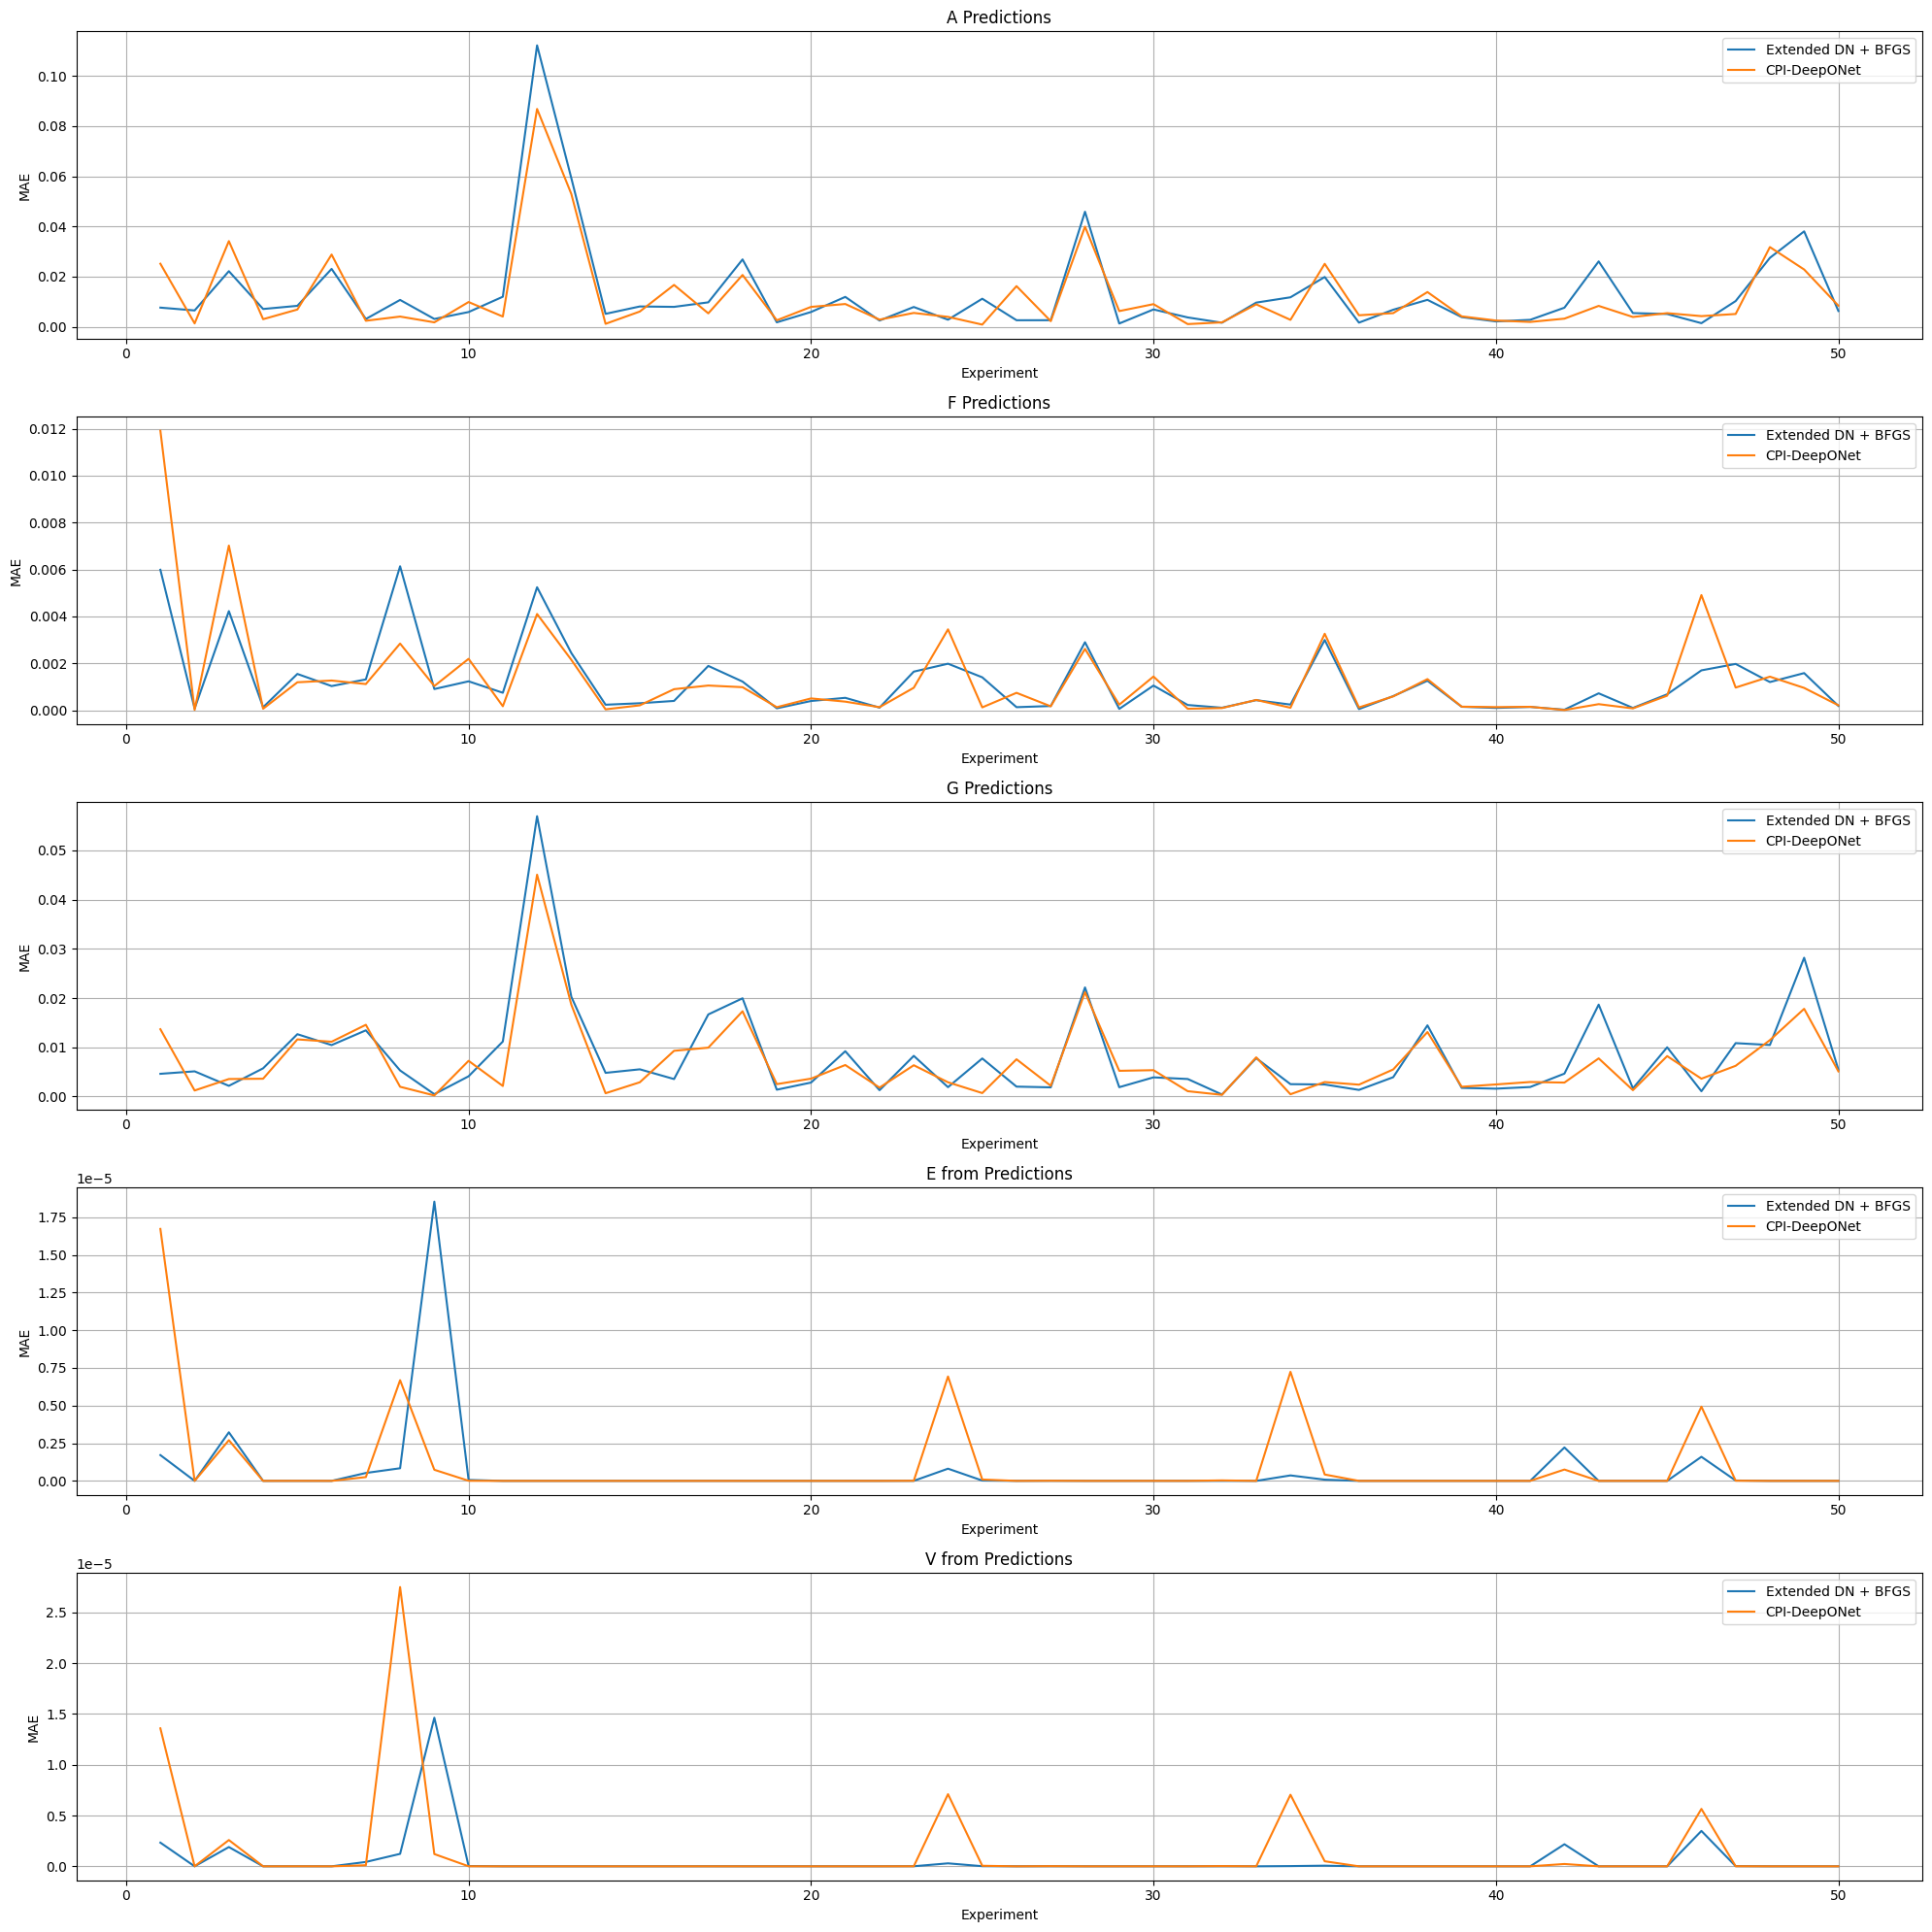

In [91]:
t_end_val = 5.0

preds, preds_error, (A_rk, F_rk, G_rk, E_rk, V_rk) = tt_run_test(num_vars = 5, num_models = 2, num_exp = 50, \
         models_lst = [var_model, Cvar_model], \
         params_lst = [params, Cparams], \
         labels_lst = ["Extended DN + BFGS", "CPI-DeepONet"], \
         bfgs_lst = [0], \
         t_end = t_end_val)

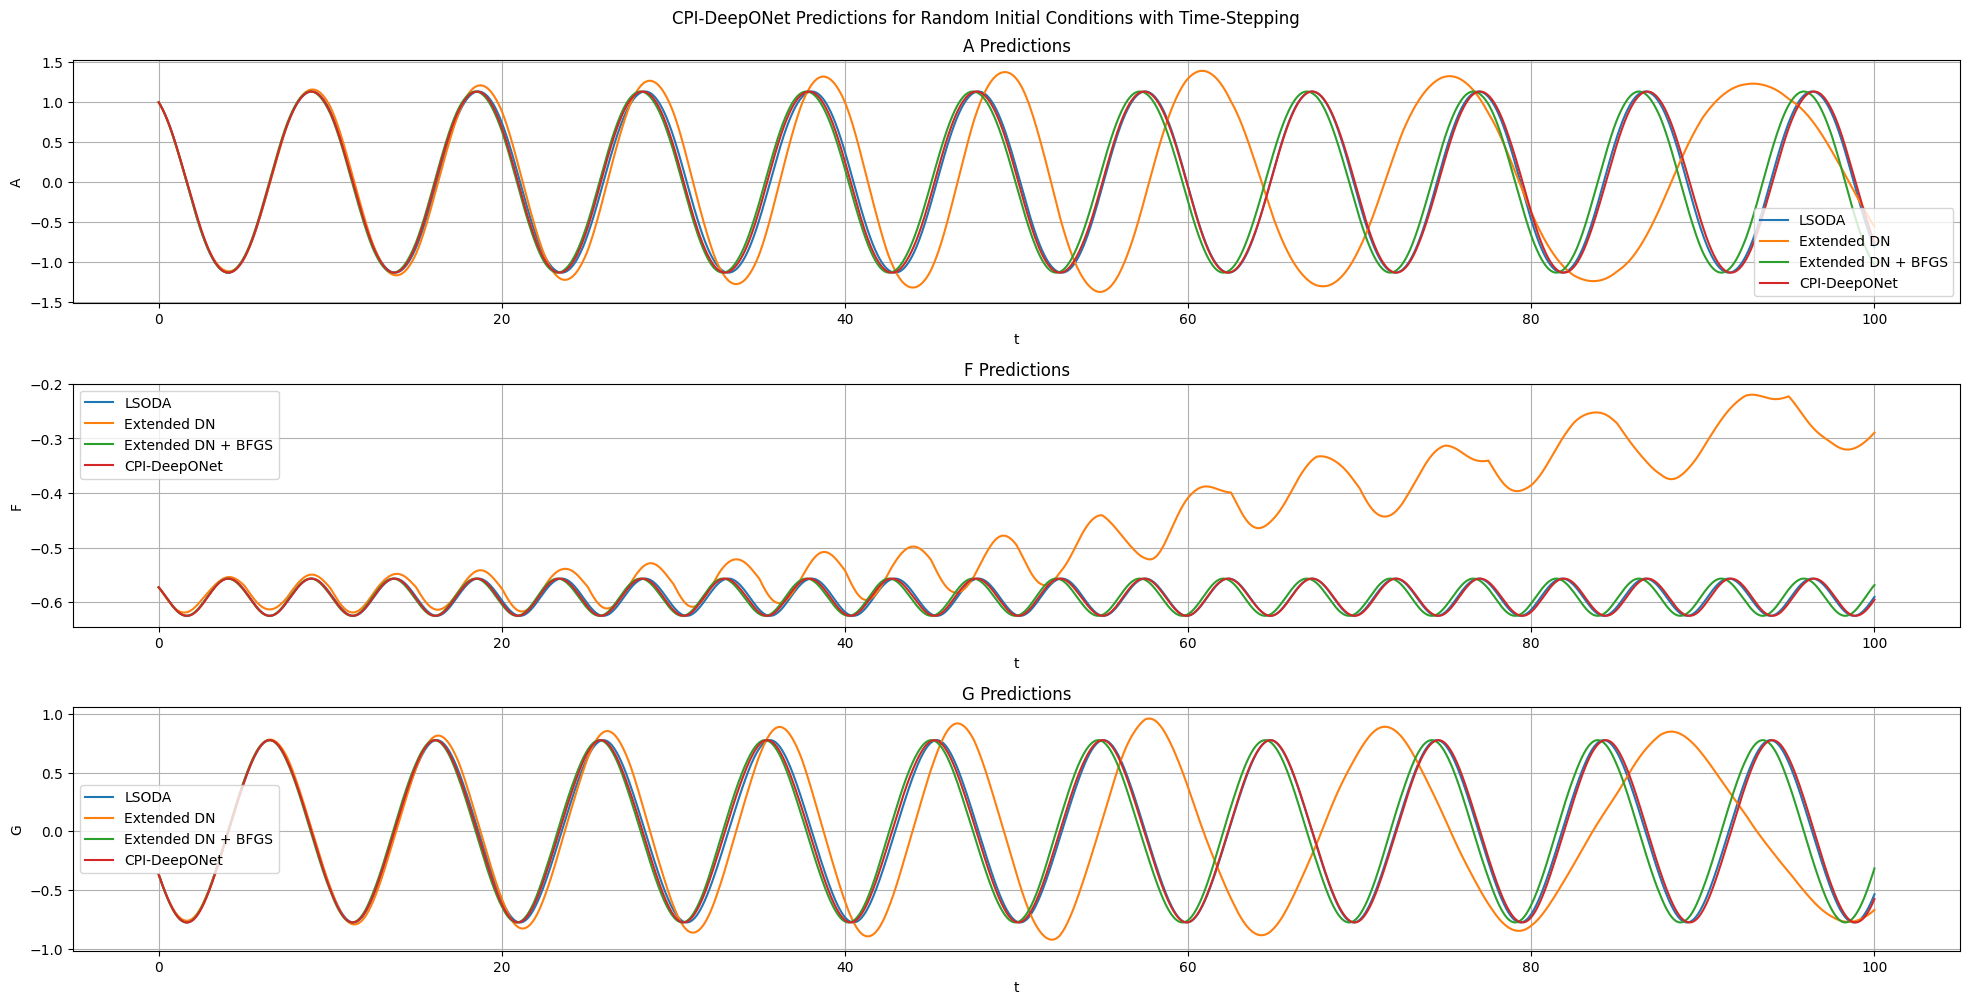

In [82]:
n = 500
t_end = t_end_val

num_cycles = int(t_end/tfinal)
n_tot = n*num_cycles
t_tot = np.linspace(t0, t_end, n_tot)



A, F, G, E, V = preds[-1, 0, :, 0, :], preds[-1, 0, :, 1, :], preds[-1, 0, :, 2, :], preds[-1, 0, :, 3, :], preds[-1, 0, :, 4, :]
A_bfgs, F_bfgs, G_bfgs, E_bfgs, V_bfgs = preds[-1, 1, :, 0, :], preds[-1, 1, :, 1, :], preds[-1, 1, :, 2, :], preds[-1, 1, :, 3, :], preds[-1, 1, :, 4, :]
CA, CF, CG, CE, CV = preds[-1, 2, :, 0, :], preds[-1, 2, :, 1, :], preds[-1, 2, :, 2, :], preds[-1, 2, :, 3, :], preds[-1, 2, :, 4, :]

fig = plt.figure(figsize=(20, 10))
fig.suptitle('CPI-DeepONet Predictions for Random Initial Conditions with Time-Stepping')


plt.subplot(3, 1, 1)
plt.tight_layout()
plt.plot(t_tot, A_rk)
plt.plot(t_tot, A.flatten())
plt.plot(t_tot, A_bfgs.flatten())
plt.plot(t_tot, CA.flatten())
plt.xlabel("t")
plt.ylabel("A")
plt.grid()
plt.legend(['LSODA', 'Extended DN', 'Extended DN + BFGS', 'CPI-DeepONet'])
plt.title("A Predictions")

plt.subplot(3, 1, 2)
plt.tight_layout()
plt.plot(t_tot, F_rk)
plt.plot(t_tot, F.flatten())
plt.plot(t_tot, F_bfgs.flatten())
plt.plot(t_tot, CF.flatten())
plt.xlabel("t")
plt.ylabel("F")
plt.grid()
plt.legend(['LSODA', 'Extended DN', 'Extended DN + BFGS', 'CPI-DeepONet'])
plt.title("F Predictions")


plt.subplot(3, 1, 3)
plt.tight_layout()
plt.plot(t_tot, G_rk)
plt.plot(t_tot, G.flatten())
plt.plot(t_tot, G_bfgs.flatten())
plt.plot(t_tot, CG.flatten())
plt.xlabel("t")
plt.ylabel("G")
plt.grid()
plt.legend(['LSODA', 'Extended DN', 'Extended DN + BFGS', 'CPI-DeepONet'])
plt.title("G Predictions")

         
# plt.subplot(1, 5, 4)
# plt.tight_layout()
# plt.plot(t_tot, E_rk)
# #plt.plot(t_tot, E.flatten())
# plt.plot(t_tot, E_bfgs.flatten())
# plt.plot(t_tot, CE.flatten())
# plt.xlabel("t")
# plt.ylabel("E")
# plt.grid()
# plt.legend(['LSODA', 'Extended DN', 'Extended DN + BFGS', 'CPI-DeepONet'])
# plt.title("E from Predictions")


# plt.subplot(1, 5, 5)
# plt.tight_layout()
# plt.plot(t_tot, V_rk)
# #plt.plot(t_tot, V.flatten())
# plt.plot(t_tot, V_bfgs.flatten())
# plt.plot(t_tot, CV.flatten())
# plt.xlabel("t")
# plt.ylabel("V")
# plt.grid()
# plt.legend(['LSODA', 'Extended DN', 'Extended DN + BFGS', 'CPI-DeepONet'])
# plt.title("V from Predictions")

plt.show()
#fig.savefig('L1960_extended_+_bfgs_+_CPI_preds_5000ep_timestep_t100.png')

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


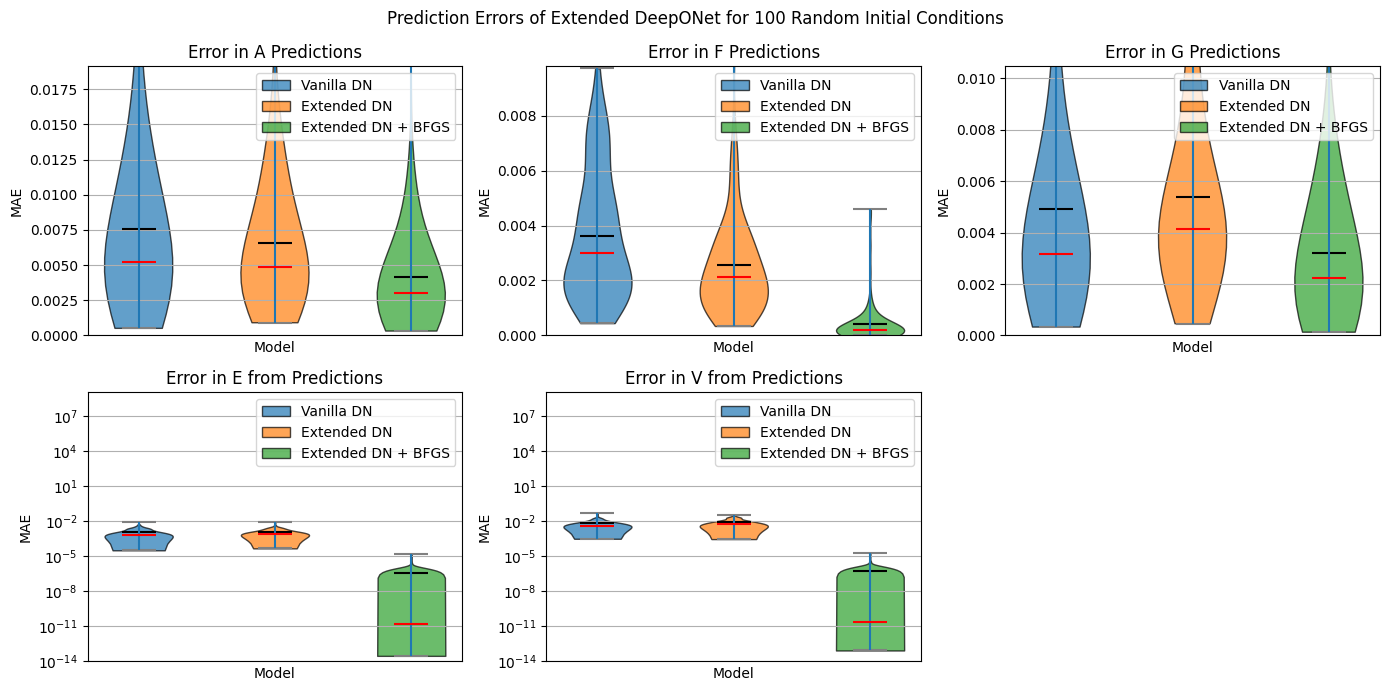

In [45]:
def run_test(num_vars, num_cons, num_models, num_exp, models_lst, params_lst, labels_lst, bfgs_lst) :

    n = 500
    t = np.linspace(t0, tfinal, n)
    
    
    preds = np.zeros((num_exp, num_models, num_vars, n))
    preds_error = np.zeros((num_exp, num_models, num_vars))

    for i in range(num_exp) :

        print(i)

        A_init = np.random.uniform(-1.0, 1.0, size=(1,))
        F_init = np.random.uniform(-1.0, 1.0, size=(1,))
        G_init = np.random.uniform(-1.0, 1.0, size=(1,))
        E_init, V_init = calc_EV(A_init, F_init, G_init)
        
        
        data_model = np.column_stack([A_init, F_init, G_init])
        data_model = np.reshape(data_model, (-1,))
        data_model = np.repeat(np.expand_dims(data_model, axis=0), n, axis=0)
        
        E_model = np.repeat(np.expand_dims(E_init, axis=0), n, axis=0)
        V_model = np.repeat(np.expand_dims(V_init, axis=0), n, axis=0)
                
        tEV_model = np.column_stack([t, E_model, V_model])
                
        data_rk = np.column_stack([A_init, F_init, G_init])
        data_rk = np.reshape(data_rk, (-1,))
        t_rk = t
            
        sol_rk = odeint(Lorenz1960, data_rk, t_rk, rtol = 1e-13, atol = 1e-13)
        A_rk, F_rk, G_rk = sol_rk[:, 0], sol_rk[:, 1], sol_rk[:, 2]
        E_rk, V_rk = calc_EV(A_rk, F_rk, G_rk)
        

        for j in range(num_models) :

            model = models_lst[j]
            params = params_lst[j]

            for k in range(num_vars - num_cons) :


                val = jax.vmap(model, [0, 0, None, None])(tEV_model, data_model, k, params)
                preds[i, j, k] = val

                
            preds[i, j, 3], preds[i, j, 4] = calc_EV(preds[i, j, 0], preds[i, j, 1], preds[i, j, 2])

            
            if j in bfgs_lst :
                
                args_arr = np.column_stack([preds[i, j, 0], preds[i, j, 1], preds[i, j, 2]])
                
                EV_arr = tEV_model[:, 1:]
        
                xbfgs = find_min_bfgs(args_arr, EV_arr)                

                for l in range(num_vars - num_cons) :

                    preds[i, j, l] = xbfgs[:, l]

                
                preds[i, j, 3], preds[i, j, 4] = calc_EV(preds[i, j, 0], preds[i, j, 1], preds[i, j, 2])  
            

            for m in range(num_vars - num_cons) :

                preds_error[i, j, m] = np.mean(np.abs(sol_rk[:, m] - preds[i, j, m]))

            preds_error[i, j, 3] = np.mean(np.abs(E_rk - preds[i, j, 3]))
            preds_error[i, j, 4] = np.mean(np.abs(V_rk - preds[i, j, 4]))
            


    x_labels = ['A', 'F', 'G', 'E', 'V'] 
        
    # Set up the figure
    fig = plt.figure(figsize=(14, 7))
    fig.suptitle('Prediction Errors of Extended DeepONet for 100 Random Initial Conditions')
    
    # Define colors for each model (adjust color palette as needed)
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']   # Example colors for each model
    
    for j in range(num_vars):
        plt.subplot(2, 3, j + 1)

        q1 = np.percentile(preds_error[:, 0, j], 25)
        q3 = np.percentile(preds_error[:, 0, j], 75)
        iqr = q3 - q1

        plt.ylim(0.0, q3 + 1.5 * iqr)
        
        # Prepare data for each model for the current variable (j)
        data = [preds_error[:, alpha, j] for alpha in range(num_models)]
        
        # Create the violin plot with custom colors
        vp = plt.violinplot(data, positions=range(num_models), showmeans=True, showmedians=True)
        
        # Customize the colors of the violins
        for i in range(num_models):
            vp['bodies'][i].set_facecolor(colors[i])  # Set face color for each model
            vp['bodies'][i].set_edgecolor('black')   # Set edge color for each model
            vp['bodies'][i].set_alpha(0.7)            # Set transparency
        
        # Customize mean and median lines
        vp['cmeans'].set_color('black')  # Mean line color
        vp['cmedians'].set_color('red')
        vp['cmins'].set_color('gray')
        vp['cmaxes'].set_color('gray')# Median line color
    
        # Add labels, title, and grid
        plt.ylabel("MAE")
        if j >= 3:
            plt.title("Error in " + x_labels[j] + " from Predictions")
        else:
            plt.title("Error in " + x_labels[j] + " Predictions")
        plt.grid(True, axis='y')
    
        # Add legend (outside the plot)
        plt.xticks([])  # Remove vertical axis ticks
        plt.xlabel("Model")  # Remove vertical axis label
        
        if j >= 3:
            plt.yscale('log')
            plt.ylim(10**(-14), 10**9)
                    
        plt.legend(labels=labels_lst, loc='upper right')
    
    # Adjust the layout and display the plot
    plt.tight_layout()
    plt.show()
    

    
    fig.savefig('L1960_extended+bfgs_violinmae_5000ep_100exps.png')
    return preds, preds_error, (A_rk, F_rk, G_rk, E_rk, V_rk)


preds, preds_error, (A_rk, F_rk, G_rk, E_rk, V_rk) = run_test(num_vars = 5, num_cons = 2, num_models = 3, num_exp = 100, \
         models_lst = [Vvar_model, var_model, var_model], \
         params_lst = [Vparams, params, params], \
         labels_lst = ['Vanilla DN', 'Extended DN', 'Extended DN + BFGS'], \
         bfgs_lst = [2])

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


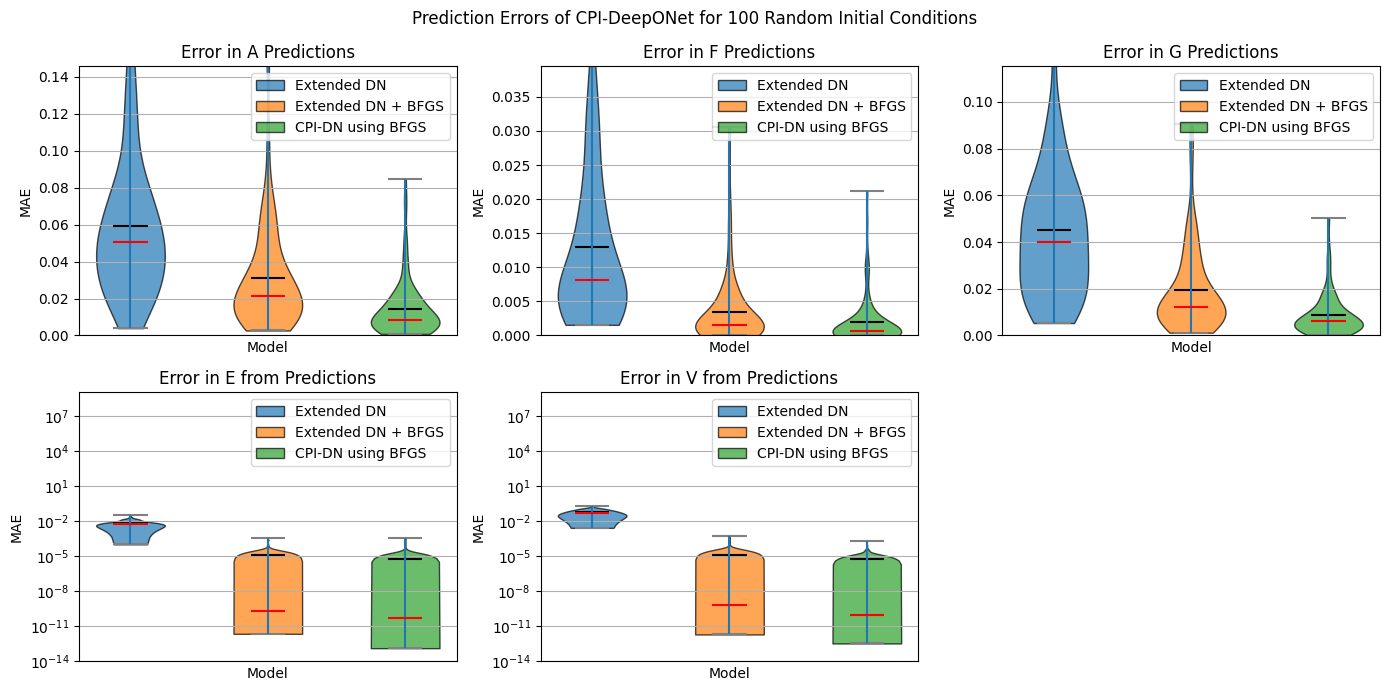

In [249]:
def tt_run_test(num_vars, num_cons, num_models, num_exp, models_lst, params_lst, labels_lst, bfgs_lst, t_end) :

    n = 500
    t = np.linspace(t0, tfinal, n)

    num_cycles = int(t_end/tfinal)
    n_ts = n*num_cycles
    t_step = tfinal/n

    
    preds = np.zeros((num_exp, num_models, num_cycles, num_vars, n))
    preds_error = np.zeros((num_exp, num_models, num_vars))

    for i in range(num_exp) :

        print(i)

        A_init = np.random.uniform(-1.0, 1.0, size=(1,))
        F_init = np.random.uniform(-1.0, 1.0, size=(1,))
        G_init = np.random.uniform(-1.0, 1.0, size=(1,))
        E_init, V_init = calc_EV(A_init, F_init, G_init)

        t = np.linspace(t0, tfinal, n)
        
        data_model = np.column_stack([A_init, F_init, G_init])
        data_model = np.reshape(data_model, (-1,))
        data_model_0 = np.repeat(np.expand_dims(data_model, axis=0), n, axis=0)
        

        E_model = np.repeat(np.expand_dims(E_init, axis=0), n, axis=0)
        V_model = np.repeat(np.expand_dims(V_init, axis=0), n, axis=0)

        EV_model = np.column_stack([E_model, V_model])
                
        tEV_model_0 = np.column_stack([t, E_model, V_model])
        
        data_rk = np.column_stack([A_init, F_init, G_init])
        data_rk = np.reshape(data_rk, (-1,))
        t_rk = np.linspace(t0, t_end, n_ts)
        
        sol_rk = odeint(Lorenz1960, data_rk, t_rk, rtol = 1e-13, atol = 1e-13)
        A_rk, F_rk, G_rk = sol_rk[:, 0], sol_rk[:, 1], sol_rk[:, 2]
        E_rk, V_rk = calc_EV(A_rk, F_rk, G_rk)
        

        for j in range(num_models) :

            model = models_lst[j]
            params = params_lst[j]


            for c in range(num_cycles) :

                if c != 0 :

                    A_init = preds[i, j, c - 1, 0, -1]
                    F_init = preds[i, j, c - 1, 1, -1]
                    G_init = preds[i, j, c - 1, 2, -1]
                    E_init, V_init = calc_EV(A_init, F_init, G_init)
                    
                    data_model = np.column_stack([A_init, F_init, G_init])
                    data_model = np.reshape(data_model, (-1,))
                    data_model = np.repeat(np.expand_dims(data_model, axis=0), n + 1, axis=0)
                    
                    E_model = np.repeat(np.expand_dims(E_init, axis=0), n + 1, axis=0)
                    V_model = np.repeat(np.expand_dims(V_init, axis=0), n + 1, axis=0)

                    t = np.linspace(t0, tfinal + t_step, n + 1)
            
                    EV_model = np.column_stack([E_model, V_model])       
                    tEV_model = np.column_stack([t, E_model, V_model])   

                else:

                    data_model = data_model_0
                    tEV_model = tEV_model_0

                
                for k in range(num_vars - num_cons) :
    
                    val = jax.vmap(model, [0, 0, None, None])(tEV_model, data_model, k, params)

                    if c != 0 :
                        preds[i, j, c, k] = val[1:]

                    else:
                        preds[i, j, c, k] = val                        
    
                preds[i, j, c, 3], preds[i, j, c, 4] = calc_EV(preds[i, j, c, 0], preds[i, j, c, 1], preds[i, j, c, 2])
    
                if j in bfgs_lst :
                    
                    args_arr = np.column_stack([preds[i, j, c, 0], preds[i, j, c, 1], preds[i, j, c, 2]])
                    
                    EV_arr = tEV_model[:, 1:] if c == 0 else tEV_model[1:, 1:]
            
                    xbfgs = find_min_bfgs(args_arr, EV_arr)                
    
                    for l in range(3) :
    
                        preds[i, j, c, l] = xbfgs[:, l]
    
                    
                    preds[i, j, c, 3], preds[i, j, c, 4] = calc_EV(preds[i, j, c, 0], preds[i, j, c, 1], preds[i, j, c, 2])  
                  
    
            for m in range(num_vars - num_cons) :
    
                preds_error[i, j, m] = np.mean(np.abs(sol_rk[:, m] - preds[i, j, :, m].flatten()))
    
            preds_error[i, j, 3] = np.mean(np.abs(E_rk - preds[i, j, :, 3].flatten()))
            preds_error[i, j, 4] = np.mean(np.abs(V_rk - preds[i, j, :, 4].flatten()))
            

    x_labels = ['A', 'F', 'G', 'E', 'V'] 
        
    # Set up the figure
    fig = plt.figure(figsize=(14, 7))
    fig.suptitle('Prediction Errors of CPI-DeepONet for 100 Random Initial Conditions')
    
    # Define colors for each model (adjust color palette as needed)
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']   # Example colors for each model
    
    for j in range(num_vars):
        plt.subplot(2, 3, j + 1)

        q1 = np.percentile(preds_error[:, 0, j], 25)
        q3 = np.percentile(preds_error[:, 0, j], 75)
        iqr = q3 - q1

        plt.ylim(0.0, q3 + 1.5 * iqr)
        
        # Prepare data for each model for the current variable (j)
        data = [preds_error[:, alpha, j] for alpha in range(num_models)]
        
        # Create the violin plot with custom colors
        vp = plt.violinplot(data, positions=range(num_models), showmeans=True, showmedians=True)
        
        # Customize the colors of the violins
        for i in range(num_models):
            vp['bodies'][i].set_facecolor(colors[i])  # Set face color for each model
            vp['bodies'][i].set_edgecolor('black')   # Set edge color for each model
            vp['bodies'][i].set_alpha(0.7)            # Set transparency
        
        # Customize mean and median lines
        vp['cmeans'].set_color('black')  # Mean line color
        vp['cmedians'].set_color('red')
        vp['cmins'].set_color('gray')
        vp['cmaxes'].set_color('gray')# Median line color
    
        # Add labels, title, and grid
        plt.ylabel("MAE")
        if j >= 3:
            plt.title("Error in " + x_labels[j] + " from Predictions")
        else:
            plt.title("Error in " + x_labels[j] + " Predictions")
        plt.grid(True, axis='y')
    
        # Add legend (outside the plot)
        plt.xticks([])  # Remove vertical axis ticks
        plt.xlabel("Model")  # Remove vertical axis label
        
        if j >= 3:
            plt.yscale('log')
            plt.ylim(10**(-14), 10**9)
                    
        plt.legend(labels=labels_lst, loc='upper right')
    
    # Adjust the layout and display the plot
    plt.tight_layout()
    plt.show()
    

    
    fig.savefig('L1960_tt10.0_cpi_violinmae_2500+2500ep_100exps.png')
    return preds, preds_error, (A_rk, F_rk, G_rk, E_rk, V_rk)

t_end_val = 10.0

preds, preds_error, (A_rk, F_rk, G_rk, E_rk, V_rk) = tt_run_test(num_vars = 5, num_cons = 2, num_models = 3, num_exp = 100, \
         models_lst = [var_model, var_model, Cvar_model], \
         params_lst = [params_5000ep, params_5000ep, Cparams], \
         labels_lst = ['Extended DN', 'Extended DN + BFGS', 'CPI-DN using BFGS'], \
         bfgs_lst = [1], \
         t_end = t_end_val)

In [119]:
@jax.jit
def loss_fun(params, t, z):

    final_loss, imp_loss = Closs(params, t, z)
    
    return final_loss


@jax.jit
def loss_grad_fun(params, t, z):
    
      return jax.grad(loss_fun, has_aux = False)(params, t, z)


@jax.jit
def loss_fun_aux(params, t, z):

    final_loss, aux_loss = Closs(params, t, z)
    
    return final_loss, aux_loss


In [120]:
@jax.jit
def computeH0(y, s):

  numerator = y.T@s
  denominator = y.T@y
  gamma = jnp.where(denominator > 0, numerator/denominator, 1.0)
  return gamma*jnp.eye(s.shape[0])

In [121]:
@jax.jit
def lineSearchBacktracking(x, p, g, t, z):       

    c1 = 1e-3
    gamma = 0.1
    max_iter = 15
  
    alpha_init = 1.0
    iter_init = 0
    
    args_init = alpha_init, iter_init

    def conditions(args) :

        alpha, iter = args
        
        xn = x + alpha*p

        params = reconstruct_pytree(tree_info, shapes, x)
        paramsn = reconstruct_pytree(tree_info, shapes, xn)
        fx = loss_fun(params, t, z)
        fxn = loss_fun(paramsn, t, z)

        cond1 = jax.lax.cond(fxn >= fx + c1*alpha*g.T@p , lambda x: True, lambda x: False, None)
        cond2 = jax.lax.cond(iter < max_iter , lambda x: True, lambda x: False, None)
        cond = jnp.logical_and(cond1, cond2)

        return cond

    def update_step(args) :

        alpha, iter = args
        
        iter = iter + 1
        alpha = alpha*gamma

        return (alpha, iter)

    
    alpha, _ = jax.lax.while_loop(conditions, update_step, args_init)   
    
    return alpha

In [122]:
@jax.jit
def body_fun_1(i, args) :

    rho, alpha, g, y, s, m = args

    i = m - i - 1
    
    rho.at[i].set(1.0 / (y[i].T @ s[i]))
    alpha.at[i].set(rho[i] * s[i].T @ g)
    g -= alpha[i] * y[i]

    return rho, alpha, g, y, s, m


@jax.jit
def body_fun_2(i, args) :

    rho, alpha, g, Hg, y, s = args
    
    beta = rho[i] * y[i].T @ Hg
    Hg += (alpha[i] - beta) * s[i]  

    return rho, alpha, g, Hg, y, s
    

In [123]:
def lbfgs(params, pdes, z, max_iters_val):

    max_iters = max_iters_val
    max_m = 5
    
    s = jnp.zeros((max_m, Cparam_count), dtype = jnp.float64)
    y = jnp.zeros((max_m, Cparam_count), dtype = jnp.float64)
    
    t = pdes
    
    losses = [loss_fun(params, t, z)]
    tree_info, shapes, x = flatten_pytree(params)
    
    g = loss_grad_fun(params,t , z)
    _, _, g = flatten_pytree(g)
    g = jnp.float64(g)

    
    for k in range(max_iters):

        m = k if k < max_m else max_m
        Hg = g if m == 0 else computeH0(y[m-1], s[m-1]) @ g

        if m > 0:

            alpha = jnp.zeros(m, dtype = jnp.float64)
            rho = jnp.zeros(m, dtype = jnp.float64)

            args_1 = (rho, alpha, g, y, s, m)
            rho, alpha, g, y, s, _ = jax.lax.fori_loop(0, m, body_fun_1, args_1)

            args_2 = (rho, alpha, g, Hg, y, s)
            rho, alpha, g, Hg, y, s = jax.lax.fori_loop(0, m, body_fun_2, args_2)

        Hg = -Hg

        eta = lineSearchBacktracking(x, Hg, g, t, z)
        xn = x + eta*Hg

        s.at[k, :].set(xn - x)
        paramsn = reconstruct_pytree(tree_info, shapes, xn)
        gn = loss_grad_fun(paramsn, t, z)
        _, _, gn = flatten_pytree(gn)

        y.at[k, :].set(gn - g)

        x = xn
        g = gn

        losses.append(loss_fun(paramsn, t, z))
     
        # if k % 10 == 0:
            
        #     print(f'Iteration: {k}, Loss: {losses[-1]}')

    _, aux_loss = loss_fun_aux(paramsn, t, z)
    print("aux loss:", aux_loss)

    return paramsn, losses

In [124]:
def Ctrain_network_lbfgs(params, des, zsensor, epochs=100):

    N = de_points.shape[0]
    
    nr_batches = 10
    batch_size = len(des)//nr_batches
    
    ds_z = tf.data.Dataset.from_tensor_slices(zsensor)
    ds_de = tf.data.Dataset.from_tensor_slices(des)
    
    ds = tf.data.Dataset.zip((ds_de, ds_z))
    ds = ds.shuffle(N).batch(batch_size)
    
    epoch_loss = np.zeros(epochs)

    for i in range(epochs):
      
        # print(i)
      
        for (des_batch, z_batch) in ds:
        
          params, loss = lbfgs(params, des_batch.numpy(), z_batch.numpy(), 5)     
          epoch_loss[i] += loss[-1]

        epoch_loss[i] /= batch_size

        if i % 10 == 0:
            print(f'Loss in epoch {i}: {epoch_loss[i]}')

    return params, epoch_loss

In [125]:
# print(de_points.shape, zsensors.shape)

In [126]:
# Cparams_flat = jnp.load("t2.5_300_ep.npy")
# Cparams = reconstruct_pytree(tree_info, shapes, Cparams_flat)

In [127]:
# epochs = 500
# Cparams, loss_lbfgs = Ctrain_network_lbfgs(Cparams, de_points, zsensors, epochs)

TypeError: iteration over a 0-d array

In [ ]:
# plt.semilogy(loss_lbfgs)
# plt.grid()

In [ ]:
# total_loss = np.concatenate((loss_adam, loss_lbfgs))

In [ ]:
# plt.semilogy(total_loss)
# plt.grid()

In [ ]:
A = jax.vmap(Cvar_model, [0, 0, None, None])(tEV, z_init, 0, Cparams)
F = jax.vmap(Cvar_model, [0, 0, None, None])(tEV, z_init, 1, Cparams)
G = jax.vmap(Cvar_model, [0, 0, None, None])(tEV, z_init, 2, Cparams)
E = (1/4)*((A**2/l**2) + (F**2/k**2) + (2*(G**2)/(k**2 + l**2)))
V = (1/2)*(A**2 + F**2 + 2*(G**2))

In [ ]:
fig = plt.figure(figsize=(12, 10))

plt.subplot(3, 5, 1)
plt.tight_layout()
plt.plot(t, A_van)
plt.plot(t, A_rk)
plt.xlabel("A")
plt.grid()
plt.legend(['Vanilla','RK45'])

plt.subplot(3, 5, 2)
plt.tight_layout()
plt.plot(t, F_van)
plt.plot(t, F_rk)
plt.xlabel("F")
plt.grid()
plt.legend(['Vanilla','RK45'])

plt.subplot(3, 5, 3)
plt.tight_layout()
plt.plot(t, G_van)
plt.plot(t, G_rk)
plt.xlabel("G")
plt.grid()
plt.legend(['Vanilla','RK45'])

plt.subplot(3, 5, 4)
plt.tight_layout()
plt.plot(t, E_van)
plt.plot(t, E_rk)
plt.xlabel("E")
plt.grid()
plt.legend(['Vanilla','RK45'])


plt.subplot(3, 5, 5)
plt.tight_layout()
plt.plot(t, V_van)
plt.plot(t, V_rk)
plt.xlabel("V")
plt.grid()
plt.legend(['Vanilla','RK45'])

plt.subplot(3, 5, 6)
plt.tight_layout()
plt.plot(t, A_bfgs)
plt.plot(t, A_rk)
plt.xlabel("A")
plt.grid()
plt.legend(['BFGS w/o Train','RK45'])

plt.subplot(3, 5, 7)
plt.tight_layout()
plt.plot(t, F_bfgs)
plt.plot(t, F_rk)
plt.xlabel("F")
plt.grid()
plt.legend(['BFGS w/o Train','RK45'])

plt.subplot(3, 5, 8)
plt.tight_layout()
plt.plot(t, G_bfgs)
plt.plot(t, G_rk)
plt.xlabel("G")
plt.grid()
plt.legend(['BFGS w/o Train','RK45'])

plt.subplot(3, 5, 9)
plt.tight_layout()
plt.plot(t, E_bfgs)
plt.plot(t, E_rk)
plt.xlabel("E")
plt.grid()
plt.legend(['BFGS w/o Train','RK45'])


plt.subplot(3, 5, 10)
plt.tight_layout()
plt.plot(t, V_bfgs)
plt.plot(t, V_rk)
plt.xlabel("V")
plt.grid()
plt.legend(['BFGS w/o Train','RK45'])


plt.subplot(3, 5, 11)
plt.tight_layout()
plt.plot(t, A)
plt.plot(t, A_rk)
plt.xlabel("A")
plt.grid()
plt.legend(['BFGS w/ Train','RK45'])

plt.subplot(3, 5, 12)
plt.tight_layout()
plt.plot(t, F)
plt.plot(t, F_rk)
plt.xlabel("F")
plt.grid()
plt.legend(['BFGS w/ Train','RK45'])

plt.subplot(3, 5, 13)
plt.tight_layout()
plt.plot(t, G)
plt.plot(t, G_rk)
plt.xlabel("G")
plt.grid()
plt.legend(['BFGS w/ Train','RK45'])

plt.subplot(3, 5, 14)
plt.tight_layout()
plt.plot(t, E)
plt.plot(t, E_rk)
plt.xlabel("E")
plt.grid()
plt.legend(['BFGS w/ Train','RK45'])


plt.subplot(3, 5, 15)
plt.tight_layout()
plt.plot(t, V)
plt.plot(t, V_rk)
plt.xlabel("V")
plt.grid()
plt.legend(['BFGS w/ Train','RK45'])


plt.show()

In [ ]:
n = 500

t = np.linspace(t0, tfinal, n)

A_data = np.random.uniform(-1.0, 1.0, size=(1,))
F_data = np.random.uniform(-1.0, 1.0, size=(1,))
G_data = np.random.uniform(-1.0, 1.0, size=(1,))

E_data = (1/4)*((A_data**2/l**2) + (F_data**2/k**2) + (2*(G_data**2)/(k**2 + l**2)))
E_data = np.repeat(np.expand_dims(E_data, axis=0), n, axis=0)

V_data = (1/2)*(A_data**2 + F_data**2 + 2*(G_data**2))
V_data = np.repeat(np.expand_dims(V_data, axis=0), n, axis=0)

tEV = np.column_stack([t, E_data, V_data])
init_data = np.column_stack([A_data, F_data, G_data])

init_data = np.reshape(init_data, (-1,))

z_init = np.repeat(np.expand_dims(init_data, axis=0), n, axis=0)


sol_rk = odeint(Lorenz1960, init_data, t, rtol = 1e-13, atol = 1e-13)
A_rk, F_rk, G_rk = sol_rk[:,0], sol_rk[:,1], sol_rk[:,2]
E_rk = (1/4)*((A_rk**2/l**2) + (F_rk**2/k**2) + (2*(G_rk**2)/(k**2 + l**2)))
V_rk = (1/2)*(A_rk**2 + F_rk**2 + 2*(G_rk**2))

A_van = jax.vmap(var_model, [0, 0, None, None])(tEV, z_init, 0, params)
F_van = jax.vmap(var_model, [0, 0, None, None])(tEV, z_init, 1, params)
G_van = jax.vmap(var_model, [0, 0, None, None])(tEV, z_init, 2, params)
E_van = (1/4)*((A_van**2/l**2) + (F_van**2/k**2) + (2*(G_van**2)/(k**2 + l**2)))
V_van = (1/2)*(A_van**2 + F_van**2 + 2*(G_van**2))

z_van = jnp.column_stack([A_van, F_van, G_van, E_van, V_van])


AFG_vals = jnp.column_stack((A_van, F_van, G_van))
E_vals = tEV[:, 1:2]
V_vals = tEV[:, 2:]


x_bfgs = find_min_bfgs(AFG_vals, E_vals, V_vals)

A_bfgs = jnp.reshape(x_bfgs[:,:1], (-1,))
F_bfgs = jnp.reshape(x_bfgs[:,1:2], (-1,))
G_bfgs = jnp.reshape(x_bfgs[:,2:3], (-1,))
E_bfgs = (1/4)*((A_bfgs**2/l**2) + (F_bfgs**2/k**2) + (2*(G_bfgs**2)/(k**2 + l**2)))
V_bfgs = (1/2)*(A_bfgs**2 + F_bfgs**2 + 2*(G_bfgs**2))

A = jax.vmap(Cvar_model, [0, 0, None, None])(tEV, z_init, 0, Cparams)
F = jax.vmap(Cvar_model, [0, 0, None, None])(tEV, z_init, 1, Cparams)
G = jax.vmap(Cvar_model, [0, 0, None, None])(tEV, z_init, 2, Cparams)
E = (1/4)*((A**2/l**2) + (F**2/k**2) + (2*(G**2)/(k**2 + l**2)))
V = (1/2)*(A**2 + F**2 + 2*(G**2))

print(A.shape, V.shape)

fig = plt.figure(figsize=(12, 10))

plt.subplot(3, 5, 1)
plt.tight_layout()
plt.plot(t, A_van)
plt.plot(t, A_rk)
plt.xlabel("A")
plt.grid()
plt.legend(['Vanilla','RK45'])

plt.subplot(3, 5, 2)
plt.tight_layout()
plt.plot(t, F_van)
plt.plot(t, F_rk)
plt.xlabel("F")
plt.grid()
plt.legend(['Vanilla','RK45'])

plt.subplot(3, 5, 3)
plt.tight_layout()
plt.plot(t, G_van)
plt.plot(t, G_rk)
plt.xlabel("G")
plt.grid()
plt.legend(['Vanilla','RK45'])

plt.subplot(3, 5, 4)
plt.tight_layout()
plt.plot(t, E_van)
plt.plot(t, E_rk)
plt.xlabel("E")
plt.grid()
plt.legend(['Vanilla','RK45'])


plt.subplot(3, 5, 5)
plt.tight_layout()
plt.plot(t, V_van)
plt.plot(t, V_rk)
plt.xlabel("V")
plt.grid()
plt.legend(['Vanilla','RK45'])

plt.subplot(3, 5, 6)
plt.tight_layout()
plt.plot(t, A_bfgs)
plt.plot(t, A_rk)
plt.xlabel("A")
plt.grid()
plt.legend(['BFGS w/o Train','RK45'])

plt.subplot(3, 5, 7)
plt.tight_layout()
plt.plot(t, F_bfgs)
plt.plot(t, F_rk)
plt.xlabel("F")
plt.grid()
plt.legend(['BFGS w/o Train','RK45'])

plt.subplot(3, 5, 8)
plt.tight_layout()
plt.plot(t, G_bfgs)
plt.plot(t, G_rk)
plt.xlabel("G")
plt.grid()
plt.legend(['BFGS w/o Train','RK45'])

plt.subplot(3, 5, 9)
plt.tight_layout()
plt.plot(t, E_bfgs)
plt.plot(t, E_rk)
plt.xlabel("E")
plt.grid()
plt.legend(['BFGS w/o Train','RK45'])


plt.subplot(3, 5, 10)
plt.tight_layout()
plt.plot(t, V_bfgs)
plt.plot(t, V_rk)
plt.xlabel("V")
plt.grid()
plt.legend(['BFGS w/o Train','RK45'])


plt.subplot(3, 5, 11)
plt.tight_layout()
plt.plot(t, A)
plt.plot(t, A_rk)
plt.xlabel("A")
plt.grid()
plt.legend(['BFGS w/ Train','RK45'])

plt.subplot(3, 5, 12)
plt.tight_layout()
plt.plot(t, F)
plt.plot(t, F_rk)
plt.xlabel("F")
plt.grid()
plt.legend(['BFGS w/ Train','RK45'])

plt.subplot(3, 5, 13)
plt.tight_layout()
plt.plot(t, G)
plt.plot(t, G_rk)
plt.xlabel("G")
plt.grid()
plt.legend(['BFGS w/ Train','RK45'])

plt.subplot(3, 5, 14)
plt.tight_layout()
plt.plot(t, E)
plt.plot(t, E_rk)
plt.xlabel("E")
plt.grid()
plt.legend(['BFGS w/ Train','RK45'])


plt.subplot(3, 5, 15)
plt.tight_layout()
plt.plot(t, V)
plt.plot(t, V_rk)
plt.xlabel("V")
plt.grid()
plt.legend(['BFGS w/ Train','RK45'])

plt.show()



fig = plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.tight_layout()
plt.plot(t, abs((A_van-A_rk)))
plt.plot(t, abs((A_bfgs-A_rk)))
plt.plot(t, abs((A-A_rk)))
plt.xlabel("Error in A")
plt.grid()
plt.legend(['Vanilla','No Train', 'Train'])

plt.subplot(1, 3, 2)
plt.tight_layout()
plt.plot(t, abs((F_van-F_rk)))
plt.plot(t, abs((F_bfgs-F_rk)))
plt.plot(t, abs((F-F_rk)))
plt.xlabel("Error in F")
plt.grid()
plt.legend(['Vanilla','No Train', 'Train'])

plt.subplot(1, 3, 3)
plt.tight_layout()
plt.plot(t, abs((G_van-G_rk)))
plt.plot(t, abs((G_bfgs-G_rk)))
plt.plot(t, abs((G-G_rk)))
plt.xlabel("Error in G")
plt.grid()
plt.legend(['Vanilla','No Train', 'Train'])

In [ ]:
def init_preds(n) :

    return np.zeros(n), np.zeros(n), np.zeros(n), np.zeros(n), np.zeros(n)

In [ ]:
def prep_train(t_data, A, F, G, E, V, model, params, n) :

    E_data = np.repeat(np.expand_dims(E, axis=0), n, axis=0)
    V_data = np.repeat(np.expand_dims(V, axis=0), n, axis=0)
    tEV_data = np.column_stack([t_data, E_data, V_data])
   
    AFG_data = np.column_stack([A, F, G])
    AFG_data = np.reshape(AFG_data, (-1,))
    AFG_data = np.repeat(np.expand_dims(AFG_data, axis=0), n, axis=0)

    A = jax.vmap(model, [0, 0, None, None])(tEV_data, AFG_data, 0, params)
    F = jax.vmap(model, [0, 0, None, None])(tEV_data, AFG_data, 1, params)
    G = jax.vmap(model, [0, 0, None, None])(tEV_data, AFG_data, 2, params)
    E = (1/4)*((A**2/l**2) + (F**2/k**2) + (2*(G**2)/(k**2 + l**2)))
    V = (1/2)*(A**2 + F**2 + 2*(G**2))   

    return A, F, G, E, V, tEV_data, AFG_data

    

In [ ]:
t_start = 0.0
t_end = 100.0

n_ts = int(n*(t_end/tfinal))

t_step = t_end/n_ts

num_cycles = math.ceil(n_ts/n)
print(t_step, n_ts, num_cycles)

t_ts = np.linspace(t_start, t_end, n_ts)

A_init = np.random.uniform(-1.0, 1.0, size=(1,))
F_init = np.random.uniform(-1.0, 1.0, size=(1,))
G_init = np.random.uniform(-1.0, 1.0, size=(1,))
E_init = (1/4)*((A_init**2/l**2) + (F_init**2/k**2) + (2*(G_init**2)/(k**2 + l**2)))
V_init = (1/2)*(A_init**2 + F_init**2 + 2*(G_init**2))

data_rk = np.column_stack([A_init, F_init, G_init])
data_rk = np.reshape(data_rk, (-1,))
t_rk = t_ts

sol_rk = odeint(Lorenz1960, data_rk, t_rk, rtol = 1e-13, atol = 1e-13)
A_rk, F_rk, G_rk = sol_rk[:,0], sol_rk[:,1], sol_rk[:,2]
E_rk = (1/4)*((A_rk**2/l**2) + (F_rk**2/k**2) + (2*(G_rk**2)/(k**2 + l**2)))
V_rk = (1/2)*(A_rk**2 + F_rk**2 + 2*(G_rk**2))

A_pred_ovan, F_pred_ovan, G_pred_ovan, E_pred_ovan, V_pred_ovan = init_preds(n_ts)

A_pred_van, F_pred_van, G_pred_van, E_pred_van, V_pred_van = init_preds(n_ts)

A_pred_bfgs, F_pred_bfgs, G_pred_bfgs, E_pred_bfgs, V_pred_bfgs = init_preds(n_ts)

A_pred_lbfgs, F_pred_lbfgs, G_pred_lbfgs, E_pred_lbfgs, V_pred_lbfgs = init_preds(n_ts)

A_data_ovan, A_data_van, A_data_bfgs, A_data_lbfgs = A_init, A_init, A_init, A_init
F_data_ovan, F_data_van, F_data_bfgs, F_data_lbfgs = F_init, F_init, F_init, F_init
G_data_ovan, G_data_van, G_data_bfgs, G_data_lbfgs = G_init, G_init, G_init, G_init
E_data_ovan, E_data_van, E_data_bfgs, E_data_lbfgs = E_init, E_init, E_init, E_init
V_data_ovan, V_data_van, V_data_bfgs, V_data_lbfgs = V_init, V_init, V_init, V_init


t_data = np.linspace(t0, tfinal, n)
t_data_sub = np.linspace(t0 + t_step, tfinal, n)


for i in range(num_cycles) :

    if i != 0 :
        t_data = t_data_sub

    A_ovan, F_ovan, G_ovan, E_ovan, V_ovan, _, _ = prep_train(t_data, 
                                                   A_data_ovan, F_data_ovan, G_data_ovan, E_data_ovan, V_data_ovan, 
                                                   Vvar_model, Vparams, n)    

    A_van, F_van, G_van, E_van, V_van, _, _ = prep_train(t_data, 
                                                   A_data_van, F_data_van, G_data_van, E_data_van, V_data_van, 
                                                   var_model, params, n)

    A_bfgs, F_bfgs, G_bfgs, E_bfgs, V_bfgs, tEV_data_bfgs, _ = prep_train(t_data, 
                                                   A_data_bfgs, F_data_bfgs, G_data_bfgs, E_data_bfgs, V_data_bfgs, 
                                                   var_model, params, n)  
    
    AFG_vals = jnp.column_stack((A_bfgs, F_bfgs, G_bfgs))
    E_vals = tEV_data_bfgs[:, 1:2]
    V_vals = tEV_data_bfgs[:, 2:]

    x_bfgs = find_min_bfgs(AFG_vals, E_vals, V_vals)

    A_bfgs = jnp.reshape(x_bfgs[:,:1], (-1,))
    F_bfgs = jnp.reshape(x_bfgs[:,1:2], (-1,))
    G_bfgs = jnp.reshape(x_bfgs[:,2:3], (-1,))
    E_bfgs = (1/4)*((A_bfgs**2/l**2) + (F_bfgs**2/k**2) + (2*(G_bfgs**2)/(k**2 + l**2)))
    V_bfgs = (1/2)*(A_bfgs**2 + F_bfgs**2 + 2*(G_bfgs**2))    
    
    A_lbfgs, F_lbfgs, G_lbfgs, E_lbfgs, V_lbfgs, _, _ = prep_train(t_data, 
                                                   A_data_lbfgs, F_data_lbfgs, G_data_lbfgs, E_data_lbfgs, V_data_lbfgs, 
                                                   Cvar_model, Cparams, n)    

    A_pred_ovan[i*n:(i+1)*n] = A_ovan
    F_pred_ovan[i*n:(i+1)*n] = F_ovan
    G_pred_ovan[i*n:(i+1)*n] = G_ovan
    E_pred_ovan[i*n:(i+1)*n] = E_ovan
    V_pred_ovan[i*n:(i+1)*n] = V_ovan

    A_pred_van[i*n:(i+1)*n] = A_van
    F_pred_van[i*n:(i+1)*n] = F_van
    G_pred_van[i*n:(i+1)*n] = G_van
    E_pred_van[i*n:(i+1)*n] = E_van
    V_pred_van[i*n:(i+1)*n] = V_van
    
    A_pred_bfgs[i*n:(i+1)*n] = A_bfgs
    F_pred_bfgs[i*n:(i+1)*n] = F_bfgs
    G_pred_bfgs[i*n:(i+1)*n] = G_bfgs
    E_pred_bfgs[i*n:(i+1)*n] = E_bfgs
    V_pred_bfgs[i*n:(i+1)*n] = V_bfgs
    
    A_pred_lbfgs[i*n:(i+1)*n] = A_lbfgs
    F_pred_lbfgs[i*n:(i+1)*n] = F_lbfgs
    G_pred_lbfgs[i*n:(i+1)*n] = G_lbfgs
    E_pred_lbfgs[i*n:(i+1)*n] = E_lbfgs
    V_pred_lbfgs[i*n:(i+1)*n] = V_lbfgs

    A_data_ovan = A_pred_ovan[(i+1)*n - 1]
    F_data_ovan = F_pred_ovan[(i+1)*n - 1]
    G_data_ovan = G_pred_ovan[(i+1)*n - 1]
    E_data_ovan = E_pred_ovan[(i+1)*n - 1]
    V_data_ovan = V_pred_ovan[(i+1)*n - 1]
 
    A_data_van = A_pred_van[(i+1)*n - 1]
    F_data_van = F_pred_van[(i+1)*n - 1]
    G_data_van = G_pred_van[(i+1)*n - 1]
    E_data_van = E_pred_van[(i+1)*n - 1]
    V_data_van = V_pred_van[(i+1)*n - 1]

    A_data_bfgs = A_pred_bfgs[(i+1)*n - 1]
    F_data_bfgs = F_pred_bfgs[(i+1)*n - 1]
    G_data_bfgs = G_pred_bfgs[(i+1)*n - 1]
    E_data_bfgs = E_pred_bfgs[(i+1)*n - 1]
    V_data_bfgs = V_pred_bfgs[(i+1)*n - 1]
    
    A_data_lbfgs = A_pred_lbfgs[(i+1)*n - 1]
    F_data_lbfgs = F_pred_lbfgs[(i+1)*n - 1]
    G_data_lbfgs = G_pred_lbfgs[(i+1)*n - 1]
    E_data_lbfgs = E_pred_lbfgs[(i+1)*n - 1]
    V_data_lbfgs = V_pred_lbfgs[(i+1)*n - 1]


fig = plt.figure(figsize=(12, 10))

plt.subplot(4, 5, 1)
plt.tight_layout()
plt.plot(t_ts, A_pred_ovan)
plt.plot(t_ts, A_rk)
plt.xlabel("A")
plt.grid()
plt.legend(['OVanilla','RK45'])

plt.subplot(4, 5, 2)
plt.tight_layout()
plt.plot(t_ts, F_pred_ovan)
plt.plot(t_ts, F_rk)
plt.xlabel("F")
plt.grid()
plt.legend(['OVanilla','RK45'])

plt.subplot(4, 5, 3)
plt.tight_layout()
plt.plot(t_ts, G_pred_ovan)
plt.plot(t_ts, G_rk)
plt.xlabel("G")
plt.grid()
plt.legend(['OVanilla','RK45'])

plt.subplot(4, 5, 4)
plt.tight_layout()
plt.plot(t_ts, E_pred_ovan)
plt.plot(t_ts, E_rk)
plt.xlabel("E")
plt.grid()
plt.legend(['OVanilla','RK45'])


plt.subplot(4, 5, 5)
plt.tight_layout()
plt.plot(t_ts, V_pred_ovan)
plt.plot(t_ts, V_rk)
plt.xlabel("V")
plt.grid()
plt.legend(['OVanilla','RK45'])

plt.subplot(4, 5, 6)
plt.tight_layout()
plt.plot(t_ts, A_pred_van)
plt.plot(t_ts, A_rk)
plt.xlabel("A")
plt.grid()
plt.legend(['Vanilla','RK45'])

plt.subplot(4, 5, 7)
plt.tight_layout()
plt.plot(t_ts, F_pred_van)
plt.plot(t_ts, F_rk)
plt.xlabel("F")
plt.grid()
plt.legend(['Vanilla','RK45'])

plt.subplot(4, 5, 8)
plt.tight_layout()
plt.plot(t_ts, G_pred_van)
plt.plot(t_ts, G_rk)
plt.xlabel("G")
plt.grid()
plt.legend(['Vanilla','RK45'])

plt.subplot(4, 5, 9)
plt.tight_layout()
plt.plot(t_ts, E_pred_van)
plt.plot(t_ts, E_rk)
plt.xlabel("E")
plt.grid()
plt.legend(['Vanilla','RK45'])


plt.subplot(4, 5, 10)
plt.tight_layout()
plt.plot(t_ts, V_pred_van)
plt.plot(t_ts, V_rk)
plt.xlabel("V")
plt.grid()
plt.legend(['Vanilla','RK45'])


plt.subplot(4, 5, 11)
plt.tight_layout()
plt.plot(t_ts, A_pred_bfgs)
plt.plot(t_ts, A_rk)
plt.xlabel("A")
plt.grid()
plt.legend(['BFGS','RK45'])

plt.subplot(4, 5, 12)
plt.tight_layout()
plt.plot(t_ts, F_pred_bfgs)
plt.plot(t_ts, F_rk)
plt.xlabel("F")
plt.grid()
plt.legend(['BFGS','RK45'])

plt.subplot(4, 5, 13)
plt.tight_layout()
plt.plot(t_ts, G_pred_bfgs)
plt.plot(t_ts, G_rk)
plt.xlabel("G")
plt.grid()
plt.legend(['BFGS','RK45'])

plt.subplot(4, 5, 14)
plt.tight_layout()
plt.plot(t_ts, E_pred_bfgs)
plt.plot(t_ts, E_rk)
plt.xlabel("E")
plt.grid()
plt.legend(['BFGS','RK45'])


plt.subplot(4, 5, 15)
plt.tight_layout()
plt.plot(t_ts, V_pred_bfgs)
plt.plot(t_ts, V_rk)
plt.xlabel("V")
plt.grid()
plt.legend(['BFGS','RK45'])

plt.subplot(4, 5, 16)
plt.tight_layout()
plt.plot(t_ts, A_pred_lbfgs)
plt.plot(t_ts, A_rk)
plt.xlabel("A")
plt.grid()
plt.legend(['LBFGS','RK45'])

plt.subplot(4, 5, 17)
plt.tight_layout()
plt.plot(t_ts, F_pred_lbfgs)
plt.plot(t_ts, F_rk)
plt.xlabel("F")
plt.grid()
plt.legend(['LBFGS','RK45'])

plt.subplot(4, 5, 18)
plt.tight_layout()
plt.plot(t_ts, G_pred_lbfgs)
plt.plot(t_ts, G_rk)
plt.xlabel("G")
plt.grid()
plt.legend(['LBFGS','RK45'])

plt.subplot(4, 5, 19)
plt.tight_layout()
plt.plot(t_ts, E_pred_lbfgs)
plt.plot(t_ts, E_rk)
plt.xlabel("E")
plt.grid()
plt.legend(['LBFGS','RK45'])


plt.subplot(4, 5, 20)
plt.tight_layout()
plt.plot(t_ts, V_pred_lbfgs)
plt.plot(t_ts, V_rk)
plt.xlabel("V")
plt.grid()
plt.legend(['LBFGS','RK45'])

In [ ]:
fig = plt.figure(figsize=(12, 10))

plt.subplot(3, 1, 1)
plt.tight_layout()
plt.plot(t_ts, A_pred_ovan)
plt.plot(t_ts, A_pred_van)
plt.plot(t_ts, A_pred_bfgs)
plt.plot(t_ts, A_pred_lbfgs)
plt.plot(t_ts, A_rk)
plt.xlabel("t")
plt.ylabel("Error in A")
plt.grid()
plt.legend(['OVanilla', 'Vanilla','BFGS', 'LBFGS', 'RK45'])
plt.show()

plt.subplot(3, 1, 1)
plt.tight_layout()
plt.plot(t_ts, F_pred_ovan)
plt.plot(t_ts, F_pred_van)
plt.plot(t_ts, F_pred_bfgs)
plt.plot(t_ts, F_pred_lbfgs)
plt.plot(t_ts, F_rk)
plt.xlabel("t")
plt.ylabel("F")
plt.grid()
plt.legend(['OVanilla', 'Vanilla','BFGS', 'LBFGS', 'RK45'])
plt.show()

plt.subplot(3, 1, 1)
plt.tight_layout()
plt.plot(t_ts, G_pred_ovan)
plt.plot(t_ts, G_pred_van)
plt.plot(t_ts, G_pred_bfgs)
plt.plot(t_ts, G_pred_lbfgs)
plt.plot(t_ts, G_rk)
plt.xlabel("t")
plt.ylabel("G")
plt.grid()
plt.legend(['OVanilla', 'Vanilla','BFGS', 'LBFGS', 'RK45'])
plt.show()

In [ ]:
fig = plt.figure(figsize=(12, 10))

plt.subplot(3, 1, 1)
plt.tight_layout()
plt.plot(t_ts, abs(A_pred_ovan - A_rk))
plt.plot(t_ts, abs(A_pred_van - A_rk))
plt.plot(t_ts, abs(A_pred_bfgs - A_rk))
plt.plot(t_ts, abs(A_pred_lbfgs - A_rk))
plt.xlabel("t")
plt.ylabel("Error in A")
plt.grid()
plt.legend(['OVanilla', 'Vanilla','BFGS', 'LBFGS'])

plt.subplot(3, 1, 2)
plt.tight_layout()
plt.plot(t_ts, abs(F_pred_ovan - F_rk))
plt.plot(t_ts, abs(F_pred_van - F_rk))
plt.plot(t_ts, abs(F_pred_bfgs - F_rk))
plt.plot(t_ts, abs(F_pred_lbfgs - F_rk))
plt.xlabel("t")
plt.ylabel("Error in F")
plt.grid()
plt.legend(['OVanilla', 'Vanilla','BFGS', 'LBFGS'])

plt.subplot(3, 1, 3)
plt.tight_layout()
plt.plot(t_ts, abs(G_pred_ovan - G_rk))
plt.plot(t_ts, abs(G_pred_van - G_rk))
plt.plot(t_ts, abs(G_pred_bfgs - G_rk))
plt.plot(t_ts, abs(G_pred_lbfgs - G_rk))
plt.xlabel("t")
plt.ylabel("Error in G")
plt.grid()
plt.legend(['OVanilla', 'Vanilla','BFGS', 'LBFGS'])

In [ ]:
# tree_info, shapes, Cparams_flat = flatten_pytree(Cparams)
# jnp.save("t2.5_300_ep", Cparams_flat)

In [ ]:
# print(A_init, F_init, G_init, E_init, V_init)
# [-0.24342532] [0.31170817] [-0.85430722] [0.10097807] [0.80804976]

In [ ]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(projection='3d')
#ax.plot(A_pred_ovan, F_pred_ovan, G_pred_ovan, label='OVanilla')
#ax.plot(A_pred_van, F_pred_van, G_pred_van, label='Vanilla')
#ax.plot(A_pred_bfgs, F_pred_bfgs, G_pred_bfgs, label='BFGS')
ax.plot(A_pred_lbfgs, F_pred_lbfgs, G_pred_lbfgs, label='LBFGS')
ax.plot(A_rk, F_rk, G_rk, linestyle='dotted', label='RK45')
ax.legend()
ax.set_xlabel('A')
ax.set_ylabel('F')
ax.set_zlabel('G')